# I-Environnement

## 1-import

In [36]:
# ============================================================
# STEP 1 — Environnement
# ============================================================
import os, math, time, csv, json
from pathlib import Path
from collections import defaultdict

!pip install codecarbon
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.models import (efficientnet_b0, EfficientNet_B0_Weights)
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              f1_score, precision_score, recall_score)
import yaml

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")
print(f"GPUs disponibles : {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i} : {torch.cuda.get_device_name(i)} "
          f"— {torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB")
print(f"PyTorch : {torch.__version__}")

# Vérifier EfficientNet
try:
    _eff = efficientnet_b0(weights=None)
    print("EfficientNet-B0 : disponible ✓")
    del _eff
except Exception as e:
    print(f"EfficientNet-B0 : erreur — {e}")

class Struct:
    def __init__(self, **entries):
        self.__dict__.update(entries)


from PIL import Image

Device  : cuda
GPUs disponibles : 2
  GPU 0 : Tesla T4 — 15.6 GB
  GPU 1 : Tesla T4 — 15.6 GB
PyTorch : 2.10.0+cu128
EfficientNet-B0 : disponible ✓


## 2-Config YAML + Struct 

In [37]:
# ============================================================
# STEP 2 — Config MS-IPS NODE21
# ============================================================
import yaml

MSIPS_NODE21_CONF = """
# optimisation
n_epoch: 250
B: 16
B_seq: 16              # ← AJOUTÉ
n_epoch_warmup: 10
lr: 0.0001
wd: 0.1

# dataset
n_class: 2
data_dir: '/kaggle/input/datasets/pshikk/node-21-dataset-untampered'
img_size: 1024
n_worker: 4
pin_memory: True
eager: True

# divers
eps: 0.000001
seed: 42
track_epochs: [0, 1]

# leviers VRAM / vitesse
use_checkpoint: False
ips_encode_batch: 128

# encodeur
enc_type: 'resnet18'   # ← NOUVEAU  ('resnet18' | 'resnet50' | 'efficientnet_b0')
pretrained: True
n_chan_in: 1
n_res_blocks: 4               # ← NOUVEAU  (ignoré pour efficientnet)

# patchifier multi-échelle
coarse_size: 128
coarse_stride: 128
fine_size: 64
fine_stride: 64

# IPS
shuffle: True
shuffle_style: 'batch'
n_token: 1
M: 10
I: 10

# agrégateur
use_pos: False
use_scale_emb: True           # ← NOUVEAU
H: 8
D: 512
D_k: 64
D_v: 64
D_inner: 2048
attn_dropout: 0.1
dropout: 0.1

# tâches
tasks:
  task0:
    id: 0
    name: 'nodule'
    act_fn: 'softmax'
    metric:
      - accuracy
      - auc
      - f1
      - precision
      - recall
"""


msips_node21_conf = Struct(**yaml.safe_load(MSIPS_NODE21_CONF))

# ── Imports EfficientNet ─────────────────────────────────────
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# ── Calculs dérivés ──────────────────────────────────────────
n_coarse = ((msips_node21_conf.img_size - msips_node21_conf.coarse_size)
             // msips_node21_conf.coarse_stride + 1) ** 2
n_fine   = ((msips_node21_conf.img_size - msips_node21_conf.fine_size)
             // msips_node21_conf.fine_stride   + 1) ** 2
n_total  = n_coarse + n_fine
n_iter   = math.ceil((n_total - msips_node21_conf.M)
                     / msips_node21_conf.I)

# ── Vérification ─────────────────────────────────────────────
print(f"Dataset     : {msips_node21_conf.data_dir}")
print(f"n_epoch     : {msips_node21_conf.n_epoch}")
print(f"img_size    : {msips_node21_conf.img_size}")
print(f"\nPatchifier multi-échelle :")
print(f"  Grossier  : {msips_node21_conf.coarse_size}×"
      f"{msips_node21_conf.coarse_size}, "
      f"stride={msips_node21_conf.coarse_stride} "
      f"→ {n_coarse} patches")
print(f"  Fin       : {msips_node21_conf.fine_size}×"
      f"{msips_node21_conf.fine_size}, "
      f"stride={msips_node21_conf.fine_stride} "
      f"→ {n_fine} patches")
print(f"  N total   : {n_total} patches/image")
print(f"\nIPS         : M={msips_node21_conf.M}, "
      f"I={msips_node21_conf.I}, "
      f"n_iter={n_iter}")
print(f"Transformer : D={msips_node21_conf.D}, "
      f"H={msips_node21_conf.H}")
print(f"Tasks       : "
      f"{[t['name'] for t in msips_node21_conf.tasks.values()]}")

# ── Comparaison IPS vs MS-IPS ────────────────────────────────
print(f"\n{'─'*45}")
print(f"{'':25} {'IPS':>8} {'MS-IPS':>8}")
print(f"{'─'*45}")
print(f"{'Encodeur':25} {'ResNet18':>8} {'EffNet-B0':>8}")
print(f"{'Params encodeur':25} {'11.7M':>8} {'4.0M':>8}")
print(f"{'N patches/image':25} {'64':>8} {n_total:>8}")
print(f"{'M sélectionnés':25} {'10':>8} "
      f"{msips_node21_conf.M:>8}")
print(f"{'Échelles':25} {'1':>8} {'2':>8}")
print(f"{'─'*45}")

Dataset     : /kaggle/input/datasets/pshikk/node-21-dataset-untampered
n_epoch     : 1
img_size    : 1024

Patchifier multi-échelle :
  Grossier  : 128×128, stride=128 → 64 patches
  Fin       : 64×64, stride=64 → 256 patches
  N total   : 320 patches/image

IPS         : M=10, I=10, n_iter=31
Transformer : D=512, H=8
Tasks       : ['nodule']

─────────────────────────────────────────────
                               IPS   MS-IPS
─────────────────────────────────────────────
Encodeur                  ResNet18 EffNet-B0
Params encodeur              11.7M     4.0M
N patches/image                 64      320
M sélectionnés                  10       10
Échelles                         1        2
─────────────────────────────────────────────


# YAML pour DDR 

In [38]:
MSIPS_DDR_CONFIG = """
# optimisation
n_epoch: 250
B: 16
B_seq: 16
n_epoch_warmup: 10
lr: 0.0001
wd: 0.1

# dataset
n_class: 5
data_dir: '/kaggle/input/datasets/samriddhibagchi/ddr-dataset-credits-to-authors/DDR-dataset'
img_size: 896
n_worker: 4
pin_memory: True
eager: True

# divers
eps: 0.000001
seed: 42
track_epochs: [0, 1]

# leviers VRAM / vitesse
use_checkpoint: False
ips_encode_batch: 128

# encodeur
enc_type: 'resnet18'
pretrained: True
n_chan_in: 3
n_res_blocks: 4

# patchifier multi-échelle
coarse_size: 128
coarse_stride: 128
fine_size: 64
fine_stride: 64

# IPS
shuffle: True
shuffle_style: 'batch'
n_token: 1
M: 10
I: 10

# agrégateur
use_pos: False
use_scale_emb: True
H: 8
D: 512
D_k: 64
D_v: 64
D_inner: 2048
attn_dropout: 0.1
dropout: 0.1

# tâches
tasks:
  task0:
    id: 0
    name: 'dr_grade'
    act_fn: 'softmax'
    metric:
      - accuracy
      - kappa
      - f1
"""

msips_ddr_conf = Struct(**yaml.safe_load(MSIPS_DDR_CONFIG))

print(f"Dataset  : {msips_ddr_conf.data_dir}")
print(f"n_class  : {msips_ddr_conf.n_class}")
print(f"enc_type : {msips_ddr_conf.enc_type}")
print(f"Tasks    : {[t['name'] for t in msips_ddr_conf.tasks.values()]}")
print(f"Métriques: {msips_ddr_conf.tasks['task0']['metric']}")

Dataset  : /kaggle/input/datasets/samriddhibagchi/ddr-dataset-credits-to-authors/DDR-dataset
n_class  : 5
enc_type : resnet18
Tasks    : ['dr_grade']
Métriques: ['accuracy', 'kappa', 'f1']


# YAML RSNA pour MSIPSNet.

In [39]:
# ============================================================
# STEP 1 — Config MS-IPS RSNA
# Multi-échelle : grossier 128px + fin 64px
# N_total = 64 (grossier) + 256 (fin) = 320 patches/image
# Aligné Han et al. 2022 : split 75/25
# ============================================================
import yaml

MSIPS_RSNA_CONFIG = """
# optimisation
n_epoch: 250
B: 16
B_seq: 16
n_epoch_warmup: 10
lr: 0.0001
wd: 0.1

# dataset
n_class: 2
data_dir: '/kaggle/input/datasets/iamtapendu/rsna-pneumonia-processed-dataset'
img_size: 1024
n_worker: 4
pin_memory: True
eager: True

# divers
eps: 0.000001
seed: 42
track_epochs: [0, 1]

# leviers VRAM
use_checkpoint: False
ips_encode_batch: 128

# encodeur
enc_type: 'resnet18'
pretrained: True
n_chan_in: 1
n_res_blocks: 4

# patchifier multi-échelle (identique NODE21)
# grossier : 1024/128 = 8×8 = 64 patches
# fin      : 1024/64  = 16×16 = 256 patches
# N_total  : 320 patches / image
coarse_size: 128
coarse_stride: 128
fine_size: 64
fine_stride: 64

# IPS
shuffle: True
shuffle_style: 'batch'
n_token: 1
M: 10
I: 10

# agrégateur
use_pos: False
use_scale_emb: True
H: 8
D: 512
D_k: 64
D_v: 64
D_inner: 2048
attn_dropout: 0.1
dropout: 0.1

# tâches
tasks:
  task0:
    id: 0
    name: 'pneumonia'
    act_fn: 'softmax'
    metric:
      - accuracy
      - auc
      - f1
      - precision
      - recall
"""

msips_rsna_conf = Struct(**yaml.safe_load(MSIPS_RSNA_CONFIG))

# ── Calculs dérivés ──────────────────────────────────────────
n_coarse = ((msips_rsna_conf.img_size - msips_rsna_conf.coarse_size)
             // msips_rsna_conf.coarse_stride + 1) ** 2
n_fine   = ((msips_rsna_conf.img_size - msips_rsna_conf.fine_size)
             // msips_rsna_conf.fine_stride   + 1) ** 2
n_total  = n_coarse + n_fine
n_iter   = math.ceil((n_total - msips_rsna_conf.M) / msips_rsna_conf.I)

print(f"Dataset     : {msips_rsna_conf.data_dir}")
print(f"n_epoch     : {msips_rsna_conf.n_epoch}")
print(f"n_chan_in   : {msips_rsna_conf.n_chan_in}  (grayscale)")
print(f"\nPatchifier multi-échelle :")
print(f"  Grossier  : {msips_rsna_conf.coarse_size}×"
      f"{msips_rsna_conf.coarse_size}, "
      f"stride={msips_rsna_conf.coarse_stride} "
      f"→ {n_coarse} patches")
print(f"  Fin       : {msips_rsna_conf.fine_size}×"
      f"{msips_rsna_conf.fine_size}, "
      f"stride={msips_rsna_conf.fine_stride} "
      f"→ {n_fine} patches")
print(f"  N total   : {n_total} patches/image")
print(f"\nIPS         : M={msips_rsna_conf.M}, "
      f"I={msips_rsna_conf.I}, "
      f"n_iter={n_iter}")
print(f"Tasks       : "
      f"{[t['name'] for t in msips_rsna_conf.tasks.values()]}")
print(f"Métriques   : "
      f"{msips_rsna_conf.tasks['task0']['metric']}")

Dataset     : /kaggle/input/datasets/iamtapendu/rsna-pneumonia-processed-dataset
n_epoch     : 1
n_chan_in   : 1  (grayscale)

Patchifier multi-échelle :
  Grossier  : 128×128, stride=128 → 64 patches
  Fin       : 64×64, stride=64 → 256 patches
  N total   : 320 patches/image

IPS         : M=10, I=10, n_iter=31
Tasks       : ['pneumonia']
Métriques   : ['accuracy', 'auc', 'f1', 'precision', 'recall']


# II-Dataset

## a-NODE21Dataset

In [40]:
# ============================================================
# STEP 3 — Dataset : NODE21DatasetMSIPS
# Différence clé vs NODE21Dataset (IPS) :
# → retourne l'IMAGE ENTIÈRE (1, H, W) pas des patches
# → le patchifier multi-échelle est dans MSIPSNet.ips()
# ============================================================
import hashlib
import numpy as np
import torch
import SimpleITK as sitk
from pathlib import Path
from torch.utils.data import Dataset
from torchvision import transforms

class NODE21DatasetMSIPS(Dataset):
    """
    Classification binaire nodule (1) / pas de nodule (0).
    Retourne l'image entière normalisée (1, 1024, 1024).
    Le découpage multi-échelle est délégué à MSIPSNet.ips().
    """

    IMG_SIZE = 1024

    @staticmethod
    def _to_split(name, seed=42):
        h = int(hashlib.md5((name + str(seed)).encode()).hexdigest(), 16)
        return 'test' if (h % 100) < 20 else 'train'

    def __init__(self, conf, train=True):
        self.tasks    = conf.tasks
        self.img_size = conf.img_size
        self.train    = train

        data_root = Path(conf.data_dir)
        proc_dir  = data_root / 'cxr_images' / 'proccessed_data' / 'images'
        orig_dir  = data_root / 'cxr_images' / 'original_data'   / 'images'

        all_samples = (
            [(f, 1) for f in sorted(proc_dir.glob('n*.mha'))] +
            [(f, 0) for f in sorted(orig_dir.glob('c*.mha'))]
        )

        split_name = 'train' if train else 'test'
        self._data = [
            (path, label) for path, label in all_samples
            if self._to_split(path.name) == split_name
        ]

        # Transforms après normalisation [0,1]
        if train:
            self.aug = transforms.Compose([
                transforms.RandomHorizontalFlip(),
                transforms.RandomRotation(5),
            ])
        else:
            self.aug = None

        pos = sum(l for _, l in self._data)
        neg = len(self._data) - pos
        print(f"{'Train' if train else 'Test'} : "
              f"{len(self._data)} images "
              f"(pos={pos}, neg={neg})")

    def __len__(self):
        return len(self._data)

    def __getitem__(self, i):
        path, label = self._data[i]

        # Charger
        arr = sitk.GetArrayFromImage(
            sitk.ReadImage(str(path))).astype(np.float32)

        # Normaliser en [0, 1]
        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-6)

        # Redimensionner si nécessaire
        if arr.shape != (self.img_size, self.img_size):
            import torch.nn.functional as F
            t = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0)
            t = F.interpolate(t, size=(self.img_size, self.img_size),
                              mode='bilinear', align_corners=False)
            arr = t.squeeze().numpy()

        # (H, W) → tensor (1, H, W)
        img = torch.from_numpy(arr).unsqueeze(0)

        # Centrer / réduire [-1, 1]
        img = (img - 0.5) / 0.5

        # Augmentations train
        if self.aug is not None:
            img = self.aug(img)

        data_dict = {'input': img}   # (1, 1024, 1024)
        for task in self.tasks.values():
            data_dict[task['name']] = label

        return data_dict


# ── Sanity check corrigé ─────────────────────────────────────
ds_train = NODE21DatasetMSIPS(msips_node21_conf, train=True)
ds_test  = NODE21DatasetMSIPS(msips_node21_conf, train=False)

print(f"Train size : {len(ds_train)}")
print(f"Test size  : {len(ds_test)}")

sample = ds_train[0]
print(f"\nInput shape : {sample['input'].shape}")   # (1, 1024, 1024)
print(f"Label       : {sample['nodule']}")
print(f"Range       : [{sample['input'].min():.3f}, "
      f"{sample['input'].max():.3f}]")

# Vérifier un positif et un négatif — correction de la compréhension
pos_indices = [i for i, (_, l) in enumerate(ds_train._data) if l == 1]
neg_indices = [i for i, (_, l) in enumerate(ds_train._data) if l == 0]

print(f"\nPositifs disponibles : {len(pos_indices)}")
print(f"Négatifs disponibles : {len(neg_indices)}")

s_pos = ds_train[pos_indices[0]]
s_neg = ds_train[neg_indices[0]]

print(f"\nPositif (n*.mha) range : "
      f"[{s_pos['input'].min():.3f}, {s_pos['input'].max():.3f}]")
print(f"Négatif (c*.mha) range : "
      f"[{s_neg['input'].min():.3f}, {s_neg['input'].max():.3f}]")

Train : 3902 images (pos=915, neg=2987)
Test : 980 images (pos=219, neg=761)
Train size : 3902
Test size  : 980

Input shape : torch.Size([1, 1024, 1024])
Label       : 1
Range       : [-1.000, 1.000]

Positifs disponibles : 915
Négatifs disponibles : 2987

Positif (n*.mha) range : [-1.000, 1.000]
Négatif (c*.mha) range : [-1.000, 1.000]


# Dataset DDR

In [41]:
class DDRDatasetMSIPS(Dataset):
    """
    DDR — rétinopathie diabétique, 5 classes (0→4).
    Retourne l'image ENTIÈRE (3, img_size, img_size).
    Le patchifier multi-échelle est délégué à MSIPSNet.ips().
    Classe 5 (ungradable) exclue automatiquement.
    """

    CLASSES = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

    def __init__(self, conf, train=True, split=None):
        self.tasks    = conf.tasks
        self.img_size = conf.img_size

        if split is None:
            split = 'train' if train else 'valid'
        assert split in ('train', 'valid', 'test'), \
            f"split doit être 'train', 'valid' ou 'test', reçu: {split}"
        self.split = split

        data_root  = Path(conf.data_dir) / 'DR_grading'
        label_file = data_root / f'{split}.txt'
        img_dir    = data_root / split

        self._data = []
        with open(label_file, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                fname, grade = parts[0], int(parts[1])
                if grade == 5:
                    continue
                img_path = img_dir / fname
                if img_path.exists():
                    self._data.append((img_path, grade))

        counts = [0] * 5
        for _, g in self._data:
            counts[g] += 1
        dist_str = ', '.join(f"C{i}={counts[i]}" for i in range(5))
        print(f"[DDRDatasetMSIPS] split={split:5s} | "
              f"{len(self._data):5d} imgs | {dist_str}")

        if split == 'train':
            self.transform = transforms.Compose([
                transforms.RandomHorizontalFlip(),
                transforms.RandomVerticalFlip(),
                transforms.RandomRotation(15),
                transforms.ColorJitter(
                    brightness=0.2, contrast=0.2,
                    saturation=0.1, hue=0.05),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])
            ])

    def __len__(self):
        return len(self._data)

    def __getitem__(self, i):
        path, label = self._data[i]
        img = Image.open(path).convert('RGB')
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        arr = np.array(img, dtype=np.float32) / 255.0
        img = torch.from_numpy(arr).permute(2, 0, 1)  # (3, H, W)
        img = self.transform(img)

        data_dict = {'input': img}  # (3, img_size, img_size)
        for task in self.tasks.values():
            data_dict[task['name']] = label
        return data_dict

# RSNADatasetMSIPS.

In [42]:
# ============================================================
# STEP 2 — RSNADatasetMSIPS
# Retourne l'image entière (1, 1024, 1024)
# Le patchifier multi-échelle est délégué à MSIPSNet.ips()
# Identique à NODE21DatasetMSIPS — adapté pour RSNA PNG
# ============================================================
import hashlib
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms


class RSNADatasetMSIPS(Dataset):
    """
    Classification binaire pneumonie RSNA.
    Retourne l'image entière normalisée (1, img_size, img_size).
    Le patchifier multi-échelle est délégué à MSIPSNet.ips().

    Label  : Target (0/1) après déduplication max par patientId.
    Split  : 75% train / 25% test par hash MD5 (aligné Han et al. 2022).
    """

    @staticmethod
    def _to_split(patient_id, seed=42):
        h = int(hashlib.md5(
            (str(patient_id) + str(seed)).encode()
        ).hexdigest(), 16)
        return 'test' if (h % 100) < 25 else 'train'

    def __init__(self, conf, train=True):
        self.tasks    = conf.tasks
        self.img_size = conf.img_size
        self.train    = train

        data_root = Path(conf.data_dir)
        img_dir   = data_root / 'Training' / 'Images'
        meta_path = data_root / 'stage2_train_metadata.csv'

        # ── Chargement + déduplication ───────────────────────
        df_raw   = pd.read_csv(meta_path)
        df_dedup = (df_raw
                    .groupby('patientId')['Target']
                    .max()
                    .reset_index())

        # ── Split 75/25 ──────────────────────────────────────
        split_name = 'train' if train else 'test'
        df_dedup['split'] = df_dedup['patientId'].apply(
            lambda pid: self._to_split(pid, seed=conf.seed))
        df_split = df_dedup[
            df_dedup['split'] == split_name
        ].reset_index(drop=True)

        # ── Construction liste (path, label) ─────────────────
        self._data = []
        missing    = 0
        for _, row in df_split.iterrows():
            img_path = img_dir / f"{row['patientId']}.png"
            if img_path.exists():
                self._data.append((img_path, int(row['Target'])))
            else:
                missing += 1

        pos = sum(l for _, l in self._data)
        neg = len(self._data) - pos
        print(f"{'Train' if train else 'Test '} : {len(self._data)} images "
              f"| pos={pos} ({100*pos/len(self._data):.1f}%) "
              f"| neg={neg} ({100*neg/len(self._data):.1f}%) "
              f"| ratio={neg/max(pos,1):.2f}:1"
              + (f" | ⚠ {missing} manquantes" if missing else ""))

        # ── Transforms ───────────────────────────────────────
        if train:
            self.aug = transforms.Compose([
                transforms.RandomHorizontalFlip(),
                transforms.RandomRotation(5),
            ])
        else:
            self.aug = None

    def __len__(self):
        return len(self._data)

    def _load_image(self, path):
        """Charge PNG grayscale → tensor [1, img_size, img_size] ∈ [-1, 1]."""
        img = Image.open(path).convert('L')
        if img.size != (self.img_size, self.img_size):
            img = img.resize(
                (self.img_size, self.img_size), Image.BILINEAR)
        arr = np.array(img, dtype=np.float32) / 255.0
        t   = torch.from_numpy(arr).unsqueeze(0)   # [1, H, W] ∈ [0, 1]
        t   = (t - 0.5) / 0.5                      # → [-1, 1]
        return t

    def __getitem__(self, i):
        path, label = self._data[i]

        img = self._load_image(path)    # [1, 1024, 1024] ∈ [-1, 1]

        if self.aug is not None:
            img = self.aug(img)

        data_dict = {'input': img}
        for task in self.tasks.values():
            data_dict[task['name']] = label
        return data_dict


# ── Sanity check ─────────────────────────────────────────────
ds_train_ms = RSNADatasetMSIPS(msips_rsna_conf, train=True)
ds_test_ms  = RSNADatasetMSIPS(msips_rsna_conf, train=False)

sample = ds_train_ms[0]
print(f"\nInput shape : {sample['input'].shape}")    # (1, 1024, 1024)
print(f"Label       : {sample['pneumonia']}")         # 0 ou 1
print(f"Range       : [{sample['input'].min():.3f}, "
      f"{sample['input'].max():.3f}]")                # [-1, 1]

labels_check = [ds_train_ms[i]['pneumonia']
                for i in range(min(200, len(ds_train_ms)))]
print(f"Labels uniques (200 premiers) : {sorted(set(labels_check))}")

Train : 20005 images | pos=4509 (22.5%) | neg=15496 (77.5%) | ratio=3.44:1
Test  : 6679 images | pos=1503 (22.5%) | neg=5176 (77.5%) | ratio=3.44:1

Input shape : torch.Size([1, 1024, 1024])
Label       : 0
Range       : [-1.000, 0.922]
Labels uniques (200 premiers) : [0, 1]


## 2- DataFactory

In [43]:
# ============================================================
# DataFactory — IPS + MS-IPS
# ============================================================
from torch.utils.data import DataLoader


class DataFactory:
    """
    Instancie train/test datasets et dataloaders.

    Usage IPS :
        factory = DataFactory(node21_conf, dataset="node21")
        train_loader, test_loader = factory.loaders()

    Usage MS-IPS :
        factory = DataFactory(msips_node21_conf, dataset="msips_node21")
        train_loader, test_loader = factory.loaders()
    """

    _registry = {
        # IPS — retourne patches (N, C, H, W)
        #"node21":       NODE21Dataset,
        # "camelyon":   CamelyonFeatures,
        # "luna":       LUNAFeatures,
        # "lungct":     LungCTFeatures,
        # "mnist":      MegapixelMNIST,
        # "traffic":    TrafficSigns,

        # MS-IPS — retourne image entière (C, H, W)
        "msips_node21": NODE21DatasetMSIPS,
        # "msips_luna": LUNADatasetMSIPS,
    }

    def __init__(self, conf, dataset="node21"):
        if dataset not in self._registry:
            raise ValueError(
                f"Dataset '{dataset}' inconnu.\n"
                f"Disponibles : {list(self._registry.keys())}")

        self.conf    = conf
        self.dataset = dataset
        cls          = self._registry[dataset]

        self.train_data = cls(conf, train=True)
        self.test_data  = cls(conf, train=False)

        print(f"DataFactory ✓ — dataset={dataset}")
        print(f"  Train : {len(self.train_data)} images")
        print(f"  Test  : {len(self.test_data)} images")

    def loaders(self):
        conf = self.conf
        train_loader = DataLoader(
            self.train_data,
            batch_size=conf.B_seq,
            shuffle=True,
            num_workers=conf.n_worker,
            pin_memory=conf.pin_memory,
            persistent_workers=True
        )
        test_loader = DataLoader(
            self.test_data,
            batch_size=conf.B_seq,
            shuffle=False,
            num_workers=conf.n_worker,
            pin_memory=conf.pin_memory,
            persistent_workers=True
        )
        print(f"  Loaders créés — batch_size={conf.B_seq}")
        print(f"  Train batches : {len(train_loader)}")
        print(f"  Test batches  : {len(test_loader)}")
        return train_loader, test_loader


# ── Vérification ─────────────────────────────────────────────
factory = DataFactory(msips_node21_conf, dataset="msips_node21")
train_loader, test_loader = factory.loaders()

# Vérifier un batch
batch = next(iter(train_loader))
print(f"\nBatch shape : {batch['input'].shape}")   # (1, 1, 1024, 1024)
print(f"Label       : {batch['nodule']}")

Train : 3902 images (pos=915, neg=2987)
Test : 980 images (pos=219, neg=761)
DataFactory ✓ — dataset=msips_node21
  Train : 3902 images
  Test  : 980 images
  Loaders créés — batch_size=16
  Train batches : 244
  Test batches  : 62

Batch shape : torch.Size([16, 1, 1024, 1024])
Label       : tensor([1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1])


# III-Architecture

In [44]:
# ============================================================
# STEP 4 — Architecture MS-IPS
# EfficientNetPatchEncoder → MultiScalePatchifier →
# ScaleEmbedding → MSTransformer → MSIPSNet
# ============================================================
import math
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights




# ── 1. EfficientNetPatchEncoder ──────────────────────────────

class MSIPSPatchEncoder(nn.Module):
    """
    Encodeur de patches pour MS-IPS.
    Supporte : resnet18 | resnet50 | efficientnet_b0
    pretrained :
        True          → poids ImageNet
        None / False  → poids aléatoires
        objet Weights → ex. ResNet18_Weights.IMAGENET1K_V1
        str           → chemin vers un .pt (state_dict)
    """

    def __init__(self, enc_type='resnet18', pretrained=True,
                 n_chan_in=1, n_res_blocks=4):
        super().__init__()
        self.enc_type = enc_type

        if enc_type in ('resnet18', 'resnet50'):
            self.output_dim, enc = self._build_resnet(
                enc_type, pretrained, n_chan_in, n_res_blocks)
            self.encoder = enc

        elif enc_type == 'efficientnet_b0':
            self.output_dim, enc = self._build_efficientnet(
                pretrained, n_chan_in)
            self.encoder = enc

        else:
            raise ValueError(
                f"enc_type '{enc_type}' non reconnu. "
                "Attendu : 'resnet18' | 'resnet50' | 'efficientnet_b0'")

    def _load_pretrained(self, net, pretrained, weights_true,
                         net_fn, net_name):
        if pretrained is True:
            net = net_fn(weights=weights_true)
            print(f"[Encoder] ImageNet ({net_name})")

        elif pretrained is None or pretrained is False:
            net = net_fn(weights=None)
            print(f"[Encoder] Poids aléatoires ({net_name})")

        elif hasattr(pretrained, 'url') or hasattr(pretrained, 'value'):
            net = net_fn(weights=pretrained)
            print(f"[Encoder] Weights torchvision : {pretrained}")

        elif isinstance(pretrained, str):
            net = net_fn(weights=None)
            state = torch.load(pretrained, map_location='cpu',
                               weights_only=True)
            if isinstance(state, dict) and 'model_state' in state:
                state = state['model_state']
            missing, unexpected = net.load_state_dict(state, strict=False)
            print(f"[Encoder] Poids depuis {pretrained}")
            if missing:
                print(f"  Manquants  : {len(missing)} clés")
            if unexpected:
                print(f"  Inattendus : {len(unexpected)} clés")

        else:
            raise ValueError(
                f"pretrained='{pretrained}' non reconnu.\n"
                "Attendu : True | None | False | "
                "Weights obj | '/path/to/weights.pt'")
        return net

    def _build_resnet(self, enc_type, pretrained, n_chan_in, n_res_blocks):
        from torchvision.models import (resnet18, resnet50,
                                        ResNet18_Weights, ResNet50_Weights)
        if enc_type == 'resnet18':
            net_fn       = resnet18
            weights_true = ResNet18_Weights.IMAGENET1K_V1
            net_name     = 'ResNet18'
            dim_map      = {2: 128, 3: 256, 4: 512}
        else:
            net_fn       = resnet50
            weights_true = ResNet50_Weights.IMAGENET1K_V1
            net_name     = 'ResNet50'
            dim_map      = {2: 512, 3: 1024, 4: 2048}

        net = net_fn(weights=None)
        net = self._load_pretrained(
            net, pretrained, weights_true, net_fn, net_name)

        # Adapter canal d'entrée
        if n_chan_in != 3:
            old_conv = net.conv1
            net.conv1 = nn.Conv2d(
                n_chan_in, 64, kernel_size=7,
                stride=2, padding=3, bias=False)
            if pretrained is not None and pretrained is not False:
                net.conv1.weight.data = \
                    old_conv.weight.data.mean(dim=1, keepdim=True)

        layers = [net.conv1, net.bn1, net.relu,
                  net.maxpool, net.layer1, net.layer2]
        if n_res_blocks >= 3:
            layers.append(net.layer3)
        if n_res_blocks >= 4:
            layers.append(net.layer4)
        layers.append(net.avgpool)

        output_dim = dim_map.get(n_res_blocks, 512)
        return output_dim, nn.Sequential(*layers)

    def _build_efficientnet(self, pretrained, n_chan_in):
        from torchvision.models import (efficientnet_b0,
                                        EfficientNet_B0_Weights)
        net_fn       = efficientnet_b0
        weights_true = EfficientNet_B0_Weights.IMAGENET1K_V1
        net          = net_fn(weights=None)
        net          = self._load_pretrained(
            net, pretrained, weights_true, net_fn, 'EfficientNet-B0')

        if n_chan_in != 3:
            old_conv = net.features[0][0]
            new_conv = nn.Conv2d(
                n_chan_in, old_conv.out_channels,
                kernel_size=old_conv.kernel_size,
                stride=old_conv.stride,
                padding=old_conv.padding,
                bias=old_conv.bias is not None)
            if pretrained is not None and pretrained is not False:
                with torch.no_grad():
                    new_conv.weight.copy_(
                        old_conv.weight.mean(dim=1, keepdim=True))
            net.features[0][0] = new_conv

        enc = nn.Sequential(net.features, net.avgpool)
        return 1280, enc

    def forward(self, x):
        out = self.encoder(x)
        return torch.flatten(out, 1)


# ── 2. MultiScalePatchifier ──────────────────────────────────

class MultiScalePatchifier(nn.Module):
    """
    Découpe une image en patches à 2 échelles.
    Retourne les deux ensembles séparément car tailles différentes.
    """

    def __init__(self, coarse_size, coarse_stride,
                 fine_size, fine_stride, img_size, n_chan):
        super().__init__()
        self.coarse_size   = coarse_size
        self.coarse_stride = coarse_stride
        self.fine_size     = fine_size
        self.fine_stride   = fine_stride
        self.img_size      = img_size
        self.n_chan        = n_chan

        self.n_coarse = ((img_size - coarse_size) // coarse_stride + 1) ** 2
        self.n_fine   = ((img_size - fine_size)   // fine_stride   + 1) ** 2
        self.n_total  = self.n_coarse + self.n_fine

    def _extract(self, img, patch_size, stride):
        """img : (C, H, W) → (N, C, patch_size, patch_size)"""
        patches = img.unfold(1, patch_size, stride) \
                     .unfold(2, patch_size, stride)
        patches = patches.permute(1, 2, 0, 3, 4)
        patches = patches.reshape(-1, self.n_chan, patch_size, patch_size)
        return patches

    def forward(self, img):
        """
        img : (C, H, W)
        returns :
            p_coarse : (N_c, C, coarse_size, coarse_size)
            p_fine   : (N_f, C, fine_size,   fine_size)
        """
        p_coarse = self._extract(img, self.coarse_size, self.coarse_stride)
        p_fine   = self._extract(img, self.fine_size,   self.fine_stride)
        return p_coarse, p_fine


# ── 3. ScaleEmbedding ────────────────────────────────────────

class ScaleEmbedding(nn.Module):
    """
    Injecte l'information d'échelle dans les features.
    Si enabled=False, se comporte comme une identité.
    """

    def __init__(self, D, n_scales=2, enabled=True):
        super().__init__()
        self.enabled = enabled
        if enabled:
            self.embedding = nn.Embedding(n_scales, D)
            nn.init.normal_(self.embedding.weight, std=0.02)

    def forward(self, features, scales):
        if not self.enabled:
            return features
        scale_emb = self.embedding(scales.to(features.device))
        if features.dim() == 3:
            return features + scale_emb.unsqueeze(0)
        return features + scale_emb

# ── 4. MSTransformer ─────────────────────────────────────────

class ScaledDotProductAttention(nn.Module):
    def __init__(self, temperature, attn_dropout=0.1):
        super().__init__()
        self.temperature = temperature
        self.dropout     = nn.Dropout(attn_dropout)

    def compute_attn(self, q, k):
        attn = torch.matmul(q / self.temperature, k.transpose(2, 3))
        attn = self.dropout(torch.softmax(attn, dim=-1))
        return attn

    def forward(self, q, k, v):
        attn   = self.compute_attn(q, k)
        output = torch.matmul(attn, v)
        return output


class MultiHeadCrossAttention(nn.Module):
    def __init__(self, n_token, H, D, D_k, D_v,
                 attn_dropout=0.1, dropout=0.1):
        super().__init__()
        self.n_token = n_token
        self.H       = H
        self.D_k     = D_k
        self.D_v     = D_v

        self.q = nn.Parameter(torch.empty((1, n_token, D)))
        nn.init.uniform_(self.q, a=-math.sqrt(1/D_k),
                                  b= math.sqrt(1/D_k))

        self.q_w = nn.Linear(D, H * D_k, bias=False)
        self.k_w = nn.Linear(D, H * D_k, bias=False)
        self.v_w = nn.Linear(D, H * D_v, bias=False)
        self.fc  = nn.Linear(H * D_v, D, bias=False)

        self.attention  = ScaledDotProductAttention(
            temperature=D_k ** 0.5, attn_dropout=attn_dropout)
        self.dropout    = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(D, eps=1e-6)

    def get_attn(self, x):
        D_k, H, n_token = self.D_k, self.H, self.n_token
        B, len_seq      = x.shape[:2]
        q = self.q_w(self.q).view(1, n_token, H, D_k)
        k = self.k_w(x).view(B, len_seq, H, D_k)
        q, k = q.transpose(1, 2), k.transpose(1, 2)
        return self.attention.compute_attn(q, k)

    def forward(self, x):
        D_k, D_v, H, n_token = self.D_k, self.D_v, self.H, self.n_token
        B, len_seq = x.shape[:2]
        q = self.q_w(self.q).view(1, n_token, H, D_k)
        k = self.k_w(x).view(B, len_seq, H, D_k)
        v = self.v_w(x).view(B, len_seq, H, D_v)
        q, k, v = q.transpose(1, 2), k.transpose(1, 2), v.transpose(1, 2)
        x = self.attention(q, k, v)
        x = x.transpose(1, 2).contiguous().view(B, n_token, -1)
        x = self.dropout(self.fc(x))
        x += self.q
        x = self.layer_norm(x)
        return x


class MLP(nn.Module):
    def __init__(self, D, D_inner, dropout=0.1):
        super().__init__()
        self.w_1        = nn.Linear(D, D_inner)
        self.w_2        = nn.Linear(D_inner, D)
        self.layer_norm = nn.LayerNorm(D, eps=1e-6)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        x = self.w_2(torch.relu(self.w_1(x)))
        x = self.dropout(x)
        x += residual
        x = self.layer_norm(x)
        return x




def pos_enc_1d(D, len_seq):
    if D % 2 != 0:
        raise ValueError(f"pos_enc_1d requiert D pair (reçu {D})")
    pe       = torch.zeros(len_seq, D)
    position = torch.arange(0, len_seq).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, D, 2, dtype=torch.float) *
                         -(math.log(10000.0) / D))
    pe[:, 0::2] = torch.sin(position.float() * div_term)
    pe[:, 1::2] = torch.cos(position.float() * div_term)
    return pe


class MSTransformer(nn.Module):
    """
    Identique au Transformer IPS original.
    Les features reçues ont déjà le scale embedding injecté.
    """
    def __init__(self, n_token, H, D, D_k, D_v,
                 D_inner, attn_dropout=0.1, dropout=0.1):
        super().__init__()
        self.crs_attn = MultiHeadCrossAttention(
            n_token, H, D, D_k, D_v,
            attn_dropout=attn_dropout, dropout=dropout)
        self.mlp = MLP(D, D_inner, dropout=dropout)

    def get_scores(self, x):
        attn = self.crs_attn.get_attn(x)
        return attn.mean(dim=1).transpose(1, 2).mean(-1)

    def forward(self, x):
        return self.mlp(self.crs_attn(x))


# ── 5. MSIPSNet ──────────────────────────────────────────────

class MSIPSNet(nn.Module):
    """
    Multi-Scale IPS Network.

    Pipeline IPS :
      image (C,H,W)
        → MultiScalePatchifier → p_coarse (N_c patches) + p_fine (N_f patches)
        → EfficientNetPatchEncoder → features (N, 1280)
        → Projector 1280 → D
        → ScaleEmbedding (inject échelle)
        → IPS itératif → Top-M patches sélectionnés

    Pipeline Forward (avec grad) :
      mem_patches (M, C, H, W) + mem_scales (M,)
        → EfficientNetPatchEncoder → (M, 1280)
        → Projector + ScaleEmbedding → (M, D)
        → MSTransformer → (1, n_token, D)
        → Output layer → preds
    """
    
    def __init__(self, device, conf):
        super().__init__()
        self.device        = device
        self.M             = conf.M
        self.I             = conf.I
        self.D             = conf.D
        self.tasks         = conf.tasks
        self.n_class       = conf.n_class
        self.shuffle       = conf.shuffle
        self.shuffle_style = conf.shuffle_style
        self.use_pos       = conf.use_pos
        self.use_scale_emb = getattr(conf, 'use_scale_emb', True)

        self.use_checkpoint   = getattr(conf, 'use_checkpoint',   False)
        self.ips_encode_batch = getattr(conf, 'ips_encode_batch', None)
    
        # Patchifier
        self.patchifier = MultiScalePatchifier(
            coarse_size=conf.coarse_size,
            coarse_stride=conf.coarse_stride,
            fine_size=conf.fine_size,
            fine_stride=conf.fine_stride,
            img_size=conf.img_size,
            n_chan=conf.n_chan_in
        )
    
        # Encodeur générique
        self.encoder = MSIPSPatchEncoder(
            enc_type=getattr(conf, 'enc_type', 'efficientnet_b0'),
            pretrained=conf.pretrained,
            n_chan_in=conf.n_chan_in,
            n_res_blocks=getattr(conf, 'n_res_blocks', 4)
        )
        enc_dim = self.encoder.output_dim
    
        # Projector enc_dim → D
        self.projector = nn.Sequential(
            nn.LayerNorm(enc_dim, elementwise_affine=False),
            nn.Linear(enc_dim, conf.D),
            nn.BatchNorm1d(conf.D),
            nn.ReLU()
        )
    
        # Scale embedding (optionnel)
        self.scale_emb = ScaleEmbedding(
            conf.D, n_scales=2, enabled=self.use_scale_emb)
    
        # Positional encoding (optionnel)
        N_total = self.patchifier.n_total
        if self.use_pos:
            self.pos_enc = pos_enc_1d(conf.D, N_total).unsqueeze(0).to(device)
        else:
            self.pos_enc = None
    
        # Transformer
        self.transf = MSTransformer(
            conf.n_token, conf.H, conf.D,
            conf.D_k, conf.D_v, conf.D_inner,
            conf.attn_dropout, conf.dropout
        )
    
        # Têtes de classification
        self.output_layers = nn.ModuleDict()
        for task in conf.tasks.values():
            act = (nn.Softmax(dim=-1) if task['act_fn'] == 'softmax'
                   else nn.Sigmoid())
            self.output_layers[task['name']] = nn.Sequential(
                nn.Linear(conf.D, conf.n_class), act)



    def _score_and_select(self, emb, M, idx):
        """
        emb : (1, N, D)
        idx : (1, N)
        returns : mem_emb (1, M, D), mem_idx (1, M)
        """
        attn    = self.transf.get_scores(emb)
        top_idx = torch.topk(attn, M, dim=-1)[1]
        mem_emb = torch.gather(
            emb, 1,
            top_idx.unsqueeze(-1).expand(-1, -1, self.D))
        mem_idx = torch.gather(idx, 1, top_idx)
        return mem_emb, mem_idx
        
    @torch.no_grad()
    def ips(self, imgs):
        """
        Iterative Patch Selection multi-échelle — version vectorisée.
    
        imgs : (B_seq, C, H, W)
        returns :
            mem_patches : (B_seq, M, C, coarse_size, coarse_size)
            mem_scales  : (B_seq, M)
            mem_idx     : (B_seq, M)
            mem_pos     : (B_seq, M, D) si use_pos else None
        """
        M, I, D  = self.M, self.I, self.D
        device   = self.device
        B_seq    = imgs.shape[0]
    
        if self.training:
            self.encoder.eval()
            self.transf.eval()
            self.projector.eval()
            self.scale_emb.eval()
    
        # 1. Patchifier — traiter chaque image, même taille donc stackable
        p_coarse_list, p_fine_list = [], []
        for b in range(B_seq):
            pc, pf = self.patchifier(imgs[b])
            p_coarse_list.append(pc)
            p_fine_list.append(pf)
    
        p_coarse = torch.stack(p_coarse_list, dim=0)  # (B, N_c, C, cs, cs)
        p_fine   = torch.stack(p_fine_list,   dim=0)  # (B, N_f, C, fs, fs)
    
        N_c = p_coarse.shape[1]
        N_f = p_fine.shape[1]
        N   = N_c + N_f
    
        scales_all = torch.cat([
            torch.zeros(N_c, dtype=torch.long),
            torch.ones(N_f,  dtype=torch.long)
        ])  # (N,)
    
        # 2. Redimensionner fins à coarse_size + concat
        p_fine_up = torch.nn.functional.interpolate(
            p_fine.view(B_seq * N_f, *p_fine.shape[2:]),
            size=(self.patchifier.coarse_size,
                  self.patchifier.coarse_size),
            mode='bilinear', align_corners=False
        ).view(B_seq, N_f, *p_coarse.shape[2:])
    
        all_patches = torch.cat([p_coarse, p_fine_up], dim=1).to(device)
        # (B_seq, N, C, coarse_size, coarse_size)
    
        # 3. Encoder toutes les patches en parallèle
        # Aplatir (B_seq, N, C, H, W) → (B_seq*N, C, H, W)
        patch_shape = all_patches.shape
        flat        = all_patches.view(B_seq * N, *patch_shape[2:])
            
        if self.ips_encode_batch is None:
            feats = self.encoder(flat)
        else:
            feats_list = []
            for i in range(0, len(flat), self.ips_encode_batch):
                feats_list.append(self.encoder(flat[i:i + self.ips_encode_batch]))
            feats = torch.cat(feats_list, dim=0)
        feats = self.projector(feats)              # (B_seq*N, D)
    
        # Scale embedding
        scales_exp = scales_all.to(device).unsqueeze(0).expand(B_seq, -1)
        scales_flat = scales_exp.reshape(B_seq * N)
        feats = self.scale_emb(feats, scales_flat) # (B_seq*N, D)
    
        feats_batch = feats.view(B_seq, N, D)      # (B_seq, N, D)
    
        # 4. Positional encoding
        if self.use_pos and self.pos_enc is not None:
            pos = self.pos_enc.expand(B_seq, -1, -1)  # (B_seq, N, D)
        else:
            pos = None
    
        # 5. IPS itératif vectorisé
        idx_all = torch.arange(
            N, dtype=torch.int64, device=device
        ).unsqueeze(0).expand(B_seq, -1)           # (B_seq, N)
    
        mem_emb = feats_batch[:, :M]               # (B_seq, M, D)
        mem_idx = idx_all[:, :M]                   # (B_seq, M)
    
        n_iter = math.ceil((N - M) / I)
        for i in range(n_iter):
            start    = i * I + M
            end      = min(start + I, N)
            iter_emb = feats_batch[:, start:end]
            iter_idx = idx_all[:, start:end]
            cat_emb  = torch.cat([mem_emb, iter_emb], dim=1)
            cat_idx  = torch.cat([mem_idx, iter_idx], dim=1)
    
            if pos is not None:
                cat_pos   = torch.gather(
                    pos, 1,
                    cat_idx.unsqueeze(-1).expand(-1, -1, D))
                score_emb = cat_emb + cat_pos
            else:
                score_emb = cat_emb
    
            # Score and select — vectorisé sur B_seq
            attn    = self.transf.get_scores(score_emb)  # (B_seq, N_cat, 1)
            top_idx = torch.topk(attn, M, dim=-1)[1]     # (B_seq, 1, M)
            top_idx = top_idx.squeeze(1)                  # (B_seq, M)
    
            mem_idx = torch.gather(cat_idx, 1, top_idx)
            mem_emb = torch.gather(
                feats_batch, 1,
                mem_idx.unsqueeze(-1).expand(-1, -1, D))
    
        # 6. Récupérer patches sélectionnés
        mem_patches = torch.gather(
            all_patches, 1,
            mem_idx.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
                   .expand(-1, -1, *patch_shape[2:])
        )  # (B_seq, M, C, coarse_size, coarse_size)
    
        mem_scales = torch.stack([
            scales_all[mem_idx[b].cpu()] for b in range(B_seq)
        ], dim=0).to(device)  # (B_seq, M)
    
        if pos is not None:
            mem_pos = torch.gather(
                pos, 1,
                mem_idx.unsqueeze(-1).expand(-1, -1, D))  # (B_seq, M, D)
        else:
            mem_pos = None
    
        if self.training:
            self.encoder.train()
            self.transf.train()
            self.projector.train()
            self.scale_emb.train()
    
        return mem_patches, mem_scales, mem_idx, mem_pos
    
    def forward(self, mem_patches, mem_scales, mem_pos=None):
        """
        mem_patches : (B, M, C, H, W)
        mem_scales  : (B, M)
        mem_pos     : (B, M, D) ou None
        """
        from torch.utils.checkpoint import checkpoint
    
        B, M = mem_patches.shape[:2]
    
        # Aplatir (B, M, C, H, W) → (B*M, C, H, W)
        flat_patches = mem_patches.view(B * M, *mem_patches.shape[2:])
        flat_scales  = mem_scales.view(B * M)
    
        if self.use_checkpoint:
            from torch.utils.checkpoint import checkpoint as ckpt
            feats = ckpt(self.encoder, flat_patches, use_reentrant=False)
        else:
            feats = self.encoder(flat_patches)
        feats = self.projector(feats)                         # (B*M, D)
        feats = self.scale_emb(feats, flat_scales)            # (B*M, D)
    
        # Reshape → (B, M, D)
        feats_b = feats.view(B, M, self.D)
    
        # Positional encoding
        if mem_pos is not None:
            feats_b = feats_b + mem_pos
    
        image_emb = self.transf(feats_b)   # (B, n_token, D)
    
        preds = {}
        for task in self.tasks.values():
            t_name, t_id = task['name'], task['id']
            preds[t_name] = self.output_layers[t_name](
                image_emb[:, t_id])
        return preds

# ── Vérification ─────────────────────────────────────────────
net = MSIPSNet(DEVICE, msips_node21_conf).to(DEVICE)
net.eval()

img_dummy = torch.rand(1, 1, 1024, 1024).to(DEVICE)

with torch.no_grad():
    mem_patches, mem_scales, mem_idx, mem_pos = net.ips(img_dummy)
    print(f"IPS output :")
    print(f"  mem_patches : {tuple(mem_patches.shape)}")
    print(f"  mem_scales  : {tuple(mem_scales.shape)}")
    print(f"  Grossiers   : {(mem_scales.cpu()==0).sum().item()}/{msips_node21_conf.M}")
    print(f"  Fins        : {(mem_scales.cpu()==1).sum().item()}/{msips_node21_conf.M}")

    preds = net(mem_patches, mem_scales)
    print(f"\nForward output :")
    for k, v in preds.items():
        print(f"  {k} : {tuple(v.shape)}")

n_params = sum(p.numel() for p in net.parameters()) / 1e6
print(f"\nParams MS-IPS : {n_params:.3f} M")

[Encoder] ImageNet (ResNet18)
IPS output :
  mem_patches : (1, 10, 1, 128, 128)
  mem_scales  : (1, 10)
  Grossiers   : 4/10
  Fins        : 6/10

Forward output :
  nodule : (1, 2)

Params MS-IPS : 14.587 M


# IV- utils/ helper

In [45]:
# ============================================================
# Cellule 5a — Logger + fonctions utilitaires
# Copié depuis utils/utils.py — fond inchangé
# ============================================================
import math
import numpy as np
from collections import defaultdict
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              f1_score, precision_score, recall_score)
import torch
import torch.nn as nn


def adjust_learning_rate(n_epoch_warmup, n_epoch, max_lr,
                         optimizer, dloader, step):
    """Ajuste le learning rate selon un schedule cosinus avec warmup."""
    max_steps    = int(n_epoch * len(dloader))
    warmup_steps = int(n_epoch_warmup * len(dloader))

    if step < warmup_steps:
        lr = max_lr * step / warmup_steps
    else:
        step      -= warmup_steps
        max_steps -= warmup_steps
        q          = 0.5 * (1 + math.cos(math.pi * step / max_steps))
        end_lr     = max_lr * 0.001
        lr         = max_lr * q + end_lr * (1 - q)

    optimizer.param_groups[0]['lr'] = lr


def shuffle_batch(x, shuffle_idx=None):
    """Mélange chaque instance du batch de la même façon."""
    if not torch.is_tensor(shuffle_idx):
        seq_len     = x.shape[1]
        shuffle_idx = torch.randperm(seq_len)
    x = x[:, shuffle_idx]
    return x, shuffle_idx


def shuffle_instance(x, axis, shuffle_idx=None):
    """Mélange chaque instance du batch différemment."""
    if not torch.is_tensor(shuffle_idx):
        shuffle_idx = torch.rand(
            x.shape[:axis+1], device=x.device).argsort(axis)

    idx_expand = shuffle_idx.clone().to(x.device)
    for _ in range(x.ndim - axis - 1):
        idx_expand.unsqueeze_(-1)
    idx_expand = idx_expand.repeat(
        *[1 for _ in range(axis+1)], *(x.shape[axis+1:]))

    x = x.gather(axis, idx_expand)
    return x, shuffle_idx


class Logger(nn.Module):
    """Stocke et calcule les statistiques de pertes et métriques."""

    def __init__(self, task_dict):
        super().__init__()
        self.task_dict    = task_dict
        self.losses_it    = defaultdict(list)
        self.losses_epoch = defaultdict(list)
        self.y_preds      = defaultdict(list)
        self.y_trues      = defaultdict(list)
        self.metrics      = defaultdict(list)

    def update(self, next_loss, next_y_pred, next_y_true):

        for task in self.task_dict.values():
            t      = task['name']
            t_metr = task['metric']
            if isinstance(t_metr, str):
                t_metr = [t_metr]

            self.losses_it[t].append(next_loss[t])

            has_auc_f1 = any(m in ['auc', 'f1', 'precision', 'recall']
                             for m in t_metr)

            if t_metr == ['accuracy']:
                y_pred = np.argmax(next_y_pred[t], axis=-1)
            elif has_auc_f1:
                raw = next_y_pred[t]
                if raw.ndim == 2:
                    y_pred = raw[:, 1].tolist()
                else:
                    y_pred = raw.tolist()
            else:
                y_pred = next_y_pred[t].tolist()

            self.y_preds[t].extend(y_pred)
            self.y_trues[t].extend(next_y_true[t])

    def compute_metric(self):

        for task in self.task_dict.values():
            t      = task['name']
            losses = self.losses_it[t]
            self.losses_epoch[t].append(np.mean(losses))

            requested = task['metric']
            if isinstance(requested, str):
                requested = [requested]

            y_true     = np.array(self.y_trues[t])
            y_pred_raw = np.array(self.y_preds[t])

            epoch_metrics = {}
            for current_metric in requested:

                if current_metric == 'accuracy':
                    if y_pred_raw.ndim == 2:
                        y_pred = np.argmax(y_pred_raw, axis=-1)
                    else:
                        y_pred = (y_pred_raw >= 0.5).astype(int)
                    epoch_metrics[current_metric] = accuracy_score(
                        y_true, y_pred)

                elif current_metric == 'multilabel_accuracy':
                    y_pred  = np.where(y_pred_raw >= 0.5, 1., 0.)
                    correct = np.all(y_pred == y_true, axis=-1).sum()
                    epoch_metrics[current_metric] = correct / len(y_true)

                elif current_metric == 'auc':
                    scores = (y_pred_raw[:, 1]
                              if y_pred_raw.ndim == 2 else y_pred_raw)
                    epoch_metrics[current_metric] = roc_auc_score(
                        y_true, scores)

                elif current_metric == 'f1':
                    if y_pred_raw.ndim == 2:
                        y_pred = np.argmax(y_pred_raw, axis=-1)
                    else:
                        y_pred = (y_pred_raw >= 0.5).astype(int)
                    epoch_metrics[current_metric] = f1_score(
                        y_true, y_pred, zero_division=0)

                elif current_metric == 'precision':
                    if y_pred_raw.ndim == 2:
                        y_pred = np.argmax(y_pred_raw, axis=-1)
                    else:
                        y_pred = (y_pred_raw >= 0.5).astype(int)
                    epoch_metrics[current_metric] = precision_score(
                        y_true, y_pred, zero_division=0)

                elif current_metric == 'recall':
                    if y_pred_raw.ndim == 2:
                        y_pred = np.argmax(y_pred_raw, axis=-1)
                    else:
                        y_pred = (y_pred_raw >= 0.5).astype(int)
                    epoch_metrics[current_metric] = recall_score(
                        y_true, y_pred, zero_division=0)

            self.metrics[t].append(epoch_metrics)

            # Réinitialisation pour la prochaine époque
            self.losses_it[t] = []
            self.y_preds[t]   = []
            self.y_trues[t]   = []

    def print_stats(self, epoch, train,epoch_real=None, **kwargs):
        
        print_str  = 'Train' if train else 'Test'
        display    = (epoch_real + 1) if epoch_real is not None else (epoch + 1)
        print_str += f" Epoch: {display}\n"

        avg_loss = 0
        for task in self.task_dict.values():
            t         = task['name']
            mean_loss = self.losses_epoch[t][epoch]
            avg_loss += mean_loss

            epoch_metrics = self.metrics[t][epoch]
            metrics_str   = ', '.join(
                f"{k}: {v:.5f}" for k, v in epoch_metrics.items())
            print_str += f"task: {t}, loss: {mean_loss:.5f}, {metrics_str}\n"

        avg_loss  /= len(self.task_dict.values())
        print_str += f"avg loss: {avg_loss:.5f}"

        for k, v in kwargs.items():
            print_str += f", {k}: {v}"
        print_str += "\n"

        print(print_str)



def plot_histories(histories, metric="loss", figsize=(12, 5)):
    """
    Trace les courbes train/val pour une métrique donnée,
    sur plusieurs runs simultanément.

    Args:
        histories : dict {run_name: history_dict}
                    — chargé via load_history() ou depuis engine.history
        metric    : "loss", "accuracy", "auc", "f1", etc.
        figsize   : taille figure

    Usage :
        # Charger plusieurs runs
        histories = {}
        for name, path in [
            ("ips_node21_v1",  "checkpoints/ips_node21_v1_history.json"),
            ("ips_node21_v2",  "checkpoints/ips_node21_v2_history.json"),
        ]:
            _, h = UniversalEngine.load_history(path)
            histories[name] = h

        # Tracer
        plot_histories(histories, metric="auc")
        plot_histories(histories, metric="loss")
    """
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import numpy as np

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    colors    = plt.cm.tab10(np.linspace(0, 1, len(histories)))

    for ax, phase in zip(axes, ["train", "val"]):
        for (run_name, history), color in zip(histories.items(), colors):
            vals = history[phase].get(metric, [])
            if not vals:
                continue
            epochs = range(1, len(vals) + 1)
            ax.plot(epochs, vals,
                    label=run_name, color=color,
                    linewidth=2, marker='o', markersize=4)

            # Annoter le meilleur point
            if phase == "val":
                best_fn = min if metric == "loss" else max
                best    = best_fn(vals)
                ep_best = vals.index(best) + 1
                ax.annotate(
                    f"{best:.4f}",
                    xy=(ep_best, best),
                    xytext=(5, 5), textcoords="offset points",
                    fontsize=8, color=color)

        ax.set_title(f"{metric} — {phase}", fontsize=12)
        ax.set_xlabel("Époque")
        ax.set_ylabel(metric)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle(f"Comparaison runs — {metric}", fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_all_metrics(histories, figsize=(16, 10)):
    """
    Grille complète : une ligne par métrique (loss + toutes métriques),
    deux colonnes (train / val).

    Usage :
        plot_all_metrics(histories)
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # Collecter toutes les métriques disponibles
    first_history = next(iter(histories.values()))
    metrics       = list(first_history["val"].keys())  # loss, accuracy, auc...

    n_rows  = len(metrics)
    fig, axes = plt.subplots(n_rows, 2,
                             figsize=(figsize[0], figsize[1] * n_rows // 2))
    if n_rows == 1:
        axes = [axes]   # forcer 2D

    colors = plt.cm.tab10(np.linspace(0, 1, len(histories)))

    for row_idx, metric in enumerate(metrics):
        for col_idx, phase in enumerate(["train", "val"]):
            ax = axes[row_idx][col_idx]

            for (run_name, history), color in zip(
                    histories.items(), colors):
                vals = history[phase].get(metric, [])
                if not vals:
                    continue
                epochs = range(1, len(vals) + 1)
                ax.plot(epochs, vals,
                        label=run_name, color=color,
                        linewidth=2, marker='o', markersize=3)

            ax.set_title(f"{metric} [{phase}]", fontsize=10)
            ax.set_xlabel("Époque")
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

    plt.suptitle("Toutes métriques — comparaison runs", fontsize=13)
    plt.tight_layout()
    plt.show()


# VRAM compute

def get_total_vram_mb():
    """Somme la VRAM peak sur tous les GPUs disponibles."""
    if not torch.cuda.is_available():
        return 0.0
    total = 0.0
    for i in range(torch.cuda.device_count()):
        total += torch.cuda.max_memory_allocated(device=i)
    return total / 1e6

# ── Vérification ────────────────────────────────────────────
log = Logger(msips_node21_conf.tasks)
print("Logger instancié ✓")
print(f"Tasks : {[t['name'] for t in msips_node21_conf.tasks.values()]}")
print(f"adjust_learning_rate : ✓")
print(f"shuffle_batch        : ✓")
print(f"shuffle_instance     : ✓")

Logger instancié ✓
Tasks : ['nodule']
adjust_learning_rate : ✓
shuffle_batch        : ✓
shuffle_instance     : ✓


# V-UniversalEngine 

In [46]:
# ============================================================
# STEP 5b — UniversalEngine MS-IPS
# Différences vs IPS :
#   - _init_batch    : buffer pour patches + scales (pas pos_enc)
#   - _fill_batch    : stocke mem_patches + mem_scales
#   - _compute_loss  : net(mem_patches, mem_scales)
#   - _train/_eval   : net.ips(img) retourne (patches, scales, idx)
# Le reste est identique à ips.ipynb
# ============================================================
import os, csv, json, time, math
import torch
import torch.nn as nn
import numpy as np


class UniversalEngineMSIPS:

    def __init__(self, net, conf, device, run_name="msips_run"):
        self.net      = net
        self.conf     = conf
        self.device   = device
        self.run_name = run_name

        if torch.cuda.device_count() > 1:
            print(f"DataParallel activé : {torch.cuda.device_count()} GPUs")
            self.net = nn.DataParallel(self.net)
        self.net.to(device)

        self.optimizer = torch.optim.AdamW(
            self.net.parameters(), lr=0, weight_decay=conf.wd)

        loss_nll = nn.NLLLoss()
        loss_bce = nn.BCELoss()
        self.criterions = {
            task['name']: loss_nll if task['act_fn'] == 'softmax'
                          else loss_bce
            for task in conf.tasks.values()
        }

        metric_names = []
        for task in conf.tasks.values():
            requested = task['metric']
            if isinstance(requested, str):
                requested = [requested]
            metric_names.extend(requested)
        self._metric_names = metric_names

        self.history = {
            "train": {"loss": [], **{m: [] for m in metric_names}},
            "val":   {"loss": [], **{m: [] for m in metric_names}},
            "lr":    [],
            "efficiency": {}
        }
        self.start_epoch = 0

        print(f"UniversalEngineMSIPS instancié ✓")
        print(f"Optimizer : AdamW")
        print(f"Critères  : {list(self.criterions.keys())}")
        print(f"History keys (train) : "
              f"{list(self.history['train'].keys())}")

    # ── Internes ─────────────────────────────────────────────

    def _init_batch(self):
        conf   = self.conf
        device = self.device
        M, C, H = conf.M, conf.n_chan_in, conf.coarse_size
    
        mem_patches = torch.zeros((conf.B, M, C, H, H)).to(device)
        mem_scales  = torch.zeros((conf.B, M), dtype=torch.long).to(device)
        mem_pos     = (torch.zeros((conf.B, M, conf.D)).to(device)
                       if conf.use_pos else None)
    
        labels = {}
        for task in conf.tasks.values():
            labels[task['name']] = torch.zeros(
                (conf.B,), dtype=torch.int64).to(device)
    
        return mem_patches, mem_scales, mem_pos, labels
    
    
    def _fill_batch(self, mem_patches, mem_scales, mem_pos, labels,
                    data, n_prep, n_prep_batch,
                    patches_iter, scales_iter, pos_iter):
        """
        patches_iter : (B_seq, M, C, H, W)
        scales_iter  : (B_seq, M)
        pos_iter     : (B_seq, M, D) ou None
        """
        B_seq = patches_iter.shape[0]
        end   = n_prep + B_seq
    
        mem_patches[n_prep:end] = patches_iter
        mem_scales[n_prep:end]  = scales_iter
        if mem_pos is not None and pos_iter is not None:
            mem_pos[n_prep:end] = pos_iter
    
        for task in self.conf.tasks.values():
            labels[task['name']][n_prep:end] = data[task['name']].to(
                labels[task['name']].device)
    
        return (mem_patches, mem_scales, mem_pos, labels,
                end, n_prep_batch + 1)
    
    
    def _shrink_batch(self, mem_patches, mem_scales, mem_pos, labels, n_prep):
        mem_patches = mem_patches[:n_prep]
        mem_scales  = mem_scales[:n_prep]
        if mem_pos is not None:
            mem_pos = mem_pos[:n_prep]
        for task in self.conf.tasks.values():
            labels[task['name']] = labels[task['name']][:n_prep]
        return mem_patches, mem_scales, mem_pos, labels
    
    
    def _compute_loss(self, mem_patches, mem_scales, mem_pos, labels):
        conf = self.conf
        net  = (self.net.module
                if isinstance(self.net, nn.DataParallel) else self.net)
    
        preds = net(mem_patches, mem_scales, mem_pos)
    
        loss        = 0
        task_losses = {}
        task_preds  = {}
        task_labels = {}
    
        for task in conf.tasks.values():
            t_name = task['name']
            pred   = preds[t_name].squeeze(-1)
            label  = labels[t_name]
    
            if task['act_fn'] == 'softmax':
                pred_loss  = torch.log(pred + conf.eps)
                label_loss = label
            else:
                pred_loss  = pred.view(-1)
                label_loss = label.float().view(-1)
    
            t_loss              = self.criterions[t_name](pred_loss, label_loss)
            task_losses[t_name] = t_loss.item()
            task_preds[t_name]  = pred.detach().cpu().numpy()
            task_labels[t_name] = label.detach().cpu().numpy()
            loss               += t_loss
    
        loss /= len(conf.tasks)
        return loss, [task_losses, task_preds, task_labels]

    # ── Train one epoch ──────────────────────────────────────

    def _train_one_epoch(self, train_loader, log_writer, epoch):
        conf   = self.conf
        device = self.device
        net    = self.net
        net.train()
    
        track_epochs = getattr(conf, 'track_epochs', [0, 1])
        if isinstance(track_epochs, bool):
            track_epochs = [0, 1] if track_epochs else []
        track = epoch in track_epochs
    
        n_prep, n_prep_batch = 0, 0
        start_new_batch      = True
    
        if track:
            if torch.cuda.is_available():
                torch.cuda.reset_peak_memory_stats()
            t0 = time.time()
    
        for data_it, data in enumerate(
                train_loader, start=epoch * len(train_loader)):
                                               
            imgs  = data['input'].to(device)  # (B_seq, C, H, W)
            
            if start_new_batch:
                mem_patches, mem_scales, mem_pos, labels = self._init_batch()
                start_new_batch = False
            
            _net = (net.module
                    if isinstance(net, nn.DataParallel) else net)
            patches_iter, scales_iter, _, pos_iter = _net.ips(imgs)
            
            (mem_patches, mem_scales, mem_pos, labels,
             n_prep, n_prep_batch) = self._fill_batch(
                mem_patches, mem_scales, mem_pos, labels, data,
                n_prep, n_prep_batch, patches_iter, scales_iter, pos_iter)
            
            batch_full    = (n_prep == conf.B)
            is_last_batch = (n_prep_batch == len(train_loader))
                
            if batch_full or is_last_batch:
                if not batch_full:
                    mem_patches, mem_scales, mem_pos, labels = \
                        self._shrink_batch(
                            mem_patches, mem_scales, mem_pos, labels, n_prep)
    
                adjust_learning_rate(
                    conf.n_epoch_warmup, conf.n_epoch,
                    conf.lr, self.optimizer,
                    train_loader, data_it + 1)
    
                self.optimizer.zero_grad()
                loss, task_info = self._compute_loss(
                    mem_patches, mem_scales, mem_pos, labels)
                task_losses, task_preds, task_labels = task_info
                loss.backward()
                self.optimizer.step()
                log_writer.update(task_losses, task_preds, task_labels)
                n_prep = 0; start_new_batch = True
    
        if track:
            elapsed = time.time() - t0
            vram_mb = get_total_vram_mb()
            if epoch not in self.history["efficiency"]:
                self.history["efficiency"][epoch] = {}
            self.history["efficiency"][epoch]["train"] = {
                "vram_mb": round(vram_mb, 1),
                "time_s":  round(elapsed, 1)
            }
    # ── Évaluation ───────────────────────────────────────────

    @torch.no_grad()
    def evaluate(self, loader, epoch=None):
        conf   = self.conf
        device = self.device
        net    = self.net
        net.eval()
    
        track_epochs = getattr(conf, 'track_epochs', [0, 1])
        if isinstance(track_epochs, bool):
            track_epochs = [0, 1] if track_epochs else []
        track = (epoch is not None) and (epoch in track_epochs)
    
        log_writer      = Logger(conf.tasks)
        n_prep, n_prep_batch = 0, 0
        start_new_batch = True
    
        if track:
            if torch.cuda.is_available():
                torch.cuda.reset_peak_memory_stats()
            t0 = time.time()
    
        for data in loader:
            imgs  = data['input'].to(device)  # (B_seq, C, H, W)
            
            if start_new_batch:
                mem_patches, mem_scales, mem_pos, labels = self._init_batch()
                start_new_batch = False
            
            _net = (net.module
                    if isinstance(net, nn.DataParallel) else net)
            patches_iter, scales_iter, _, pos_iter = _net.ips(imgs)
            
            (mem_patches, mem_scales, mem_pos, labels,
             n_prep, n_prep_batch) = self._fill_batch(
                mem_patches, mem_scales, mem_pos, labels, data,
                n_prep, n_prep_batch, patches_iter, scales_iter, pos_iter)
            
            batch_full    = (n_prep == conf.B)
            is_last_batch = (n_prep_batch == len(loader))
    
            if batch_full or is_last_batch:
                if not batch_full:
                    mem_patches, mem_scales, mem_pos, labels = \
                        self._shrink_batch(
                            mem_patches, mem_scales, mem_pos, labels, n_prep)
                _, task_info = self._compute_loss(
                    mem_patches, mem_scales, mem_pos, labels)
                task_losses, task_preds, task_labels = task_info
                log_writer.update(task_losses, task_preds, task_labels)
                n_prep = 0; start_new_batch = True
    
        if track:
            elapsed = time.time() - t0
            vram_mb = get_total_vram_mb()
            if epoch not in self.history["efficiency"]:
                self.history["efficiency"][epoch] = {}
            self.history["efficiency"][epoch]["val"] = {
                "vram_mb": round(vram_mb, 1),
                "time_s":  round(elapsed, 1)
            }
    
        return log_writer
    # ── Boucle complète ──────────────────────────────────────

    # ── Checkpoint ───────────────────────────────────────────

    def save(self, path):
        os.makedirs(os.path.dirname(os.path.abspath(path)),
                    exist_ok=True)
        net_state = (self.net.module.state_dict()
                     if isinstance(self.net, nn.DataParallel)
                     else self.net.state_dict())

        def _to_native(obj):
            if isinstance(obj, dict):
                return {k: _to_native(v) for k, v in obj.items()}
            if isinstance(obj, list):
                return [_to_native(v) for v in obj]
            if hasattr(obj, 'item'):
                return obj.item()
            return obj

        torch.save({
            "epoch":           len(self.history["train"]["loss"]),
            "model_state":     net_state,
            "optimizer_state": self.optimizer.state_dict(),
            "history":         _to_native(self.history),
            "run_name":        self.run_name
        }, path)
        print(f"Checkpoint sauvegardé : {path}")

    def save_weights(self, path):
        net_state = (self.net.module.state_dict()
                     if isinstance(self.net, nn.DataParallel)
                     else self.net.state_dict())
        torch.save(net_state, path)
        print(f"Poids sauvegardés : {path}")

    def load(self, path):
        ckpt = torch.load(
            path, map_location=self.device, weights_only=False)
        net  = (self.net.module
                if isinstance(self.net, nn.DataParallel) else self.net)
        net.load_state_dict(ckpt["model_state"])
        self.optimizer.load_state_dict(ckpt["optimizer_state"])
        self.history     = ckpt["history"]
        self.start_epoch = ckpt["epoch"]
        print(f"Checkpoint chargé : {path} "
              f"(reprise époque {self.start_epoch})")

    def load_weights(self, path):
        state = torch.load(
            path, map_location=self.device, weights_only=True)
        net   = (self.net.module
                 if isinstance(self.net, nn.DataParallel) else self.net)
        net.load_state_dict(state)
        print(f"Poids chargés : {path}")

    def save_history(self, path=None):
        if path is None:
            path = f"/kaggle/working/{self.run_name}_history.json"
        def _to_native(obj):
            if isinstance(obj, dict):
                return {k: _to_native(v) for k, v in obj.items()}
            if isinstance(obj, list):
                return [_to_native(v) for v in obj]
            if hasattr(obj, 'item'):
                return obj.item()
            return obj
        with open(path, "w") as f:
            json.dump({"run_name": self.run_name,
                       "history":  _to_native(self.history)}, f, indent=2)
        print(f"History sauvegardée : {path}")

    # ── Résumé ───────────────────────────────────────────────

    def summary(self):
        net = (self.net.module
               if isinstance(self.net, nn.DataParallel) else self.net)
        n_params = sum(p.numel() for p in net.parameters()) / 1e6
        print(f"\n{'='*50}")
        print(f"Run        : {self.run_name}")
        print(f"Paramètres : {n_params:.3f} M")
        if self.history["val"]["loss"]:
            print(f"\n── Meilleurs scores (val) ──")
            best_loss = min(self.history['val']['loss'])
            ep_loss   = self.history['val']['loss'].index(best_loss)
            print(f"  {'loss':12s} : {best_loss:.5f} "
                  f"(époque {ep_loss+1})")
            for m in self._metric_names:
                vals = self.history["val"].get(m, [])
                if not vals: continue
                best = max(vals)
                ep   = vals.index(best)
                print(f"  {m:12s} : {best:.5f} (époque {ep+1})")
        if self.history["efficiency"]:
            print(f"\n── Efficiency ──")
            for ep, eff in sorted(
                    self.history["efficiency"].items()):
                for phase, stats in eff.items():
                    print(f"  Époque {ep} [{phase}] : "
                          f"VRAM={stats['vram_mb']:.0f} MB, "
                          f"temps={stats['time_s']:.1f} s")
        print(f"{'='*50}\n")

   

    def predict(self, img, return_patches=True):
        """
        Inférence sur une image entière.
    
        Args:
            img           : tensor (C, H, W) ou (1, C, H, W)
            return_patches: si True, retourne patches + scales + scores
    
        Returns:
            result : dict {
                'probs'    : {task_name: np.array (n_class,)}
                'label'    : {task_name: int}
                'patches'  : np.array (M, C, H, W)
                'scales'   : np.array (M,)
                'scores'   : np.array (M,)
                'grid_idx' : np.array (M,)
            }
        """
        conf   = self.conf
        device = self.device
        net    = (self.net.module
                  if isinstance(self.net, nn.DataParallel) else self.net)
        net.eval()
    
        if img.dim() == 3:
            img = img.unsqueeze(0)  # (1, C, H, W)
    
        with torch.no_grad():
            img_dev = img.to(device)
    
            # ── IPS ─────────────────────────────────────────────
            mem_patches, mem_scales, mem_idx, mem_pos = net.ips(img_dev)
            # mem_patches : (B, M, C, H, W)
            # mem_scales  : (B, M)
    
            # ── Scores d'attention ───────────────────────────────
            B_pred, M_pred = mem_patches.shape[:2]
            flat_patches   = mem_patches.view(B_pred * M_pred, *mem_patches.shape[2:])
            flat_scales    = mem_scales.view(B_pred * M_pred)
    
            feats   = net.encoder(flat_patches)             # (B*M, enc_dim)
            feats   = net.projector(feats)                  # (B*M, D)
            feats   = net.scale_emb(feats, flat_scales)     # (B*M, D)
            feats_b = feats.view(B_pred, M_pred, net.D)     # (B, M, D)
    
            if mem_pos is not None:
                feats_b = feats_b + mem_pos
    
            attn_scores = net.transf.get_scores(
                feats_b).squeeze(0).cpu().numpy()           # (M,)
    
            # ── Forward ──────────────────────────────────────────
            preds = net(mem_patches, mem_scales, mem_pos)
    
            result = {'probs': {}, 'label': {}}
            for task in conf.tasks.values():
                t_name = task['name']
                prob   = preds[t_name].squeeze(0).cpu().numpy()
                result['probs'][t_name] = prob
                if task['act_fn'] == 'softmax':
                    result['label'][t_name] = int(np.argmax(prob))
                else:
                    result['label'][t_name] = int(prob >= 0.5)
    
            if return_patches:
                result['patches']  = mem_patches.squeeze(0).cpu().numpy()  # (M, C, H, W)
                result['scales']   = mem_scales.squeeze(0).cpu().numpy()   # (M,)
                result['scores']   = attn_scores                           # (M,)
                result['grid_idx'] = mem_idx.squeeze(0).cpu().numpy()      # (M,)
    
        return result
            
    



    @staticmethod
    def load_history(path):
        """
        Charge un fichier history JSON.
        Retourne (run_name, history_dict).
        Méthode statique — pas besoin d'instancier l'engine.
        """
        import json
        with open(path, "r") as f:
            payload = json.load(f)
        print(f"History chargée : {path} "
              f"({payload['history']['train']['loss'].__len__()} époques)")
        return payload["run_name"], payload["history"]


# ── Vérification ─────────────────────────────────────────────
net_check = MSIPSNet(DEVICE, msips_node21_conf)
engine    = UniversalEngineMSIPS(
    net_check, msips_node21_conf, DEVICE,
    run_name="msips_node21_v1")

ds_test  = NODE21DatasetMSIPS(msips_node21_conf, train=False)
sample   = ds_test[0]
img_check = sample['input']   # (1, 1024, 1024)

result = engine.predict(img_check, return_patches=True)
print(f"Probs     : {result['probs']}")
print(f"Label     : {result['label']}")
print(f"Patches   : {result['patches'].shape}")
print(f"Scales    : {result['scales']}")
print(f"Scores    : {result['scores'].shape}")
print(f"Grossiers : {(result['scales']==0).sum()}/{msips_node21_conf.M}")
print(f"Fins      : {(result['scales']==1).sum()}/{msips_node21_conf.M}")


# ── Vérification ─────────────────────────────────────────────
net_check = MSIPSNet(DEVICE, msips_node21_conf)
engine    = UniversalEngineMSIPS(
    net_check, msips_node21_conf, DEVICE,
    run_name="msips_node21_v1")
print(f"History keys (train) : "
      f"{list(engine.history['train'].keys())}")

[Encoder] ImageNet (ResNet18)
DataParallel activé : 2 GPUs
UniversalEngineMSIPS instancié ✓
Optimizer : AdamW
Critères  : ['nodule']
History keys (train) : ['loss', 'accuracy', 'auc', 'f1', 'precision', 'recall']
Test : 980 images (pos=219, neg=761)
Probs     : {'nodule': array([0.2688641, 0.7311359], dtype=float32)}
Label     : {'nodule': 1}
Patches   : (10, 1, 128, 128)
Scales    : [0 0 0 0 1 1 1 0 1 0]
Scores    : (10,)
Grossiers : 6/10
Fins      : 4/10
[Encoder] ImageNet (ResNet18)
DataParallel activé : 2 GPUs
UniversalEngineMSIPS instancié ✓
Optimizer : AdamW
Critères  : ['nodule']
History keys (train) : ['loss', 'accuracy', 'auc', 'f1', 'precision', 'recall']
History keys (train) : ['loss', 'accuracy', 'auc', 'f1', 'precision', 'recall']


## universal + show_saliency, save_saliency, show_saliency_from_disk

In [47]:
# ============================================================
# Cellule 5 — Saliency MS-IPS
# show_saliency, save_saliency, show_saliency_from_disk
# ============================================================
import os, random, csv, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch


# ── Helpers internes ─────────────────────────────────────────

def _msips_patches_npy_path(save_dir, run_name, img_rank, image_id):
    return os.path.join(
        save_dir,
        f"{run_name}_patches_{img_rank:02d}_img{image_id}.npy"
    )


def _msips_score_range(scores):
    valid = scores[np.isfinite(scores)]
    vmin  = float(valid.min()) if len(valid) else 0.0
    vmax  = float(valid.max()) if len(valid) else 1.0
    if (vmax - vmin) < 0.01:
        mid  = (vmin + vmax) / 2.0
        vmin = mid - 0.005
        vmax = mid + 0.005
    return vmin, vmax


def _msips_build_heatmap(scores, grid_idx, scales, conf):
    img_size      = conf.img_size
    coarse_size   = conf.coarse_size
    coarse_stride = conf.coarse_stride
    fine_size     = conf.fine_size
    fine_stride   = conf.fine_stride

    n_coarse_cols = (img_size - coarse_size) // coarse_stride + 1
    n_fine_cols   = (img_size - fine_size)   // fine_stride   + 1
    n_coarse      = n_coarse_cols ** 2

    heatmap     = np.zeros((img_size, img_size), dtype=np.float32)
    vmin, vmax  = _msips_score_range(scores)
    score_range = vmax - vmin + 1e-8

    for i, (idx, scale) in enumerate(zip(grid_idx, scales)):
        norm_score = (scores[i] - vmin) / score_range
        idx   = int(idx)
        scale = int(scale)

        if scale == 0:
            r    = (idx // n_coarse_cols) * coarse_stride
            c    = (idx  % n_coarse_cols) * coarse_stride
            size = coarse_size
        else:
            idx_f = idx - n_coarse
            r     = (idx_f // n_fine_cols) * fine_stride
            c     = (idx_f  % n_fine_cols) * fine_stride
            size  = fine_size

        heatmap[r:r+size, c:c+size] = np.maximum(
            heatmap[r:r+size, c:c+size], norm_score)

    return heatmap, vmin, vmax, n_coarse_cols, n_fine_cols, n_coarse


def _msips_draw_top_patches(ax, patches_np, scores, scales, ps,
                             n_ch, K=10, vmin=None, vmax=None):
    order    = np.argsort(scores)[::-1]
    n_col_p  = 5
    n_row_p  = math.ceil(K / n_col_p)

    if vmin is None or vmax is None:
        vmin, vmax = _msips_score_range(scores)

    norm     = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap_hot = plt.cm.hot

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    if n_ch == 1:
        grid_p = np.zeros((n_row_p * ps, n_col_p * ps))
    else:
        grid_p = np.zeros((n_row_p * ps, n_col_p * ps, 3))

    for k in range(K):
        r, c     = k // n_col_p, k % n_col_p
        patch_np = patches_np[order[k]]

        if n_ch == 1:
            p = (patch_np[0] + 1) / 2
            grid_p[r*ps:(r+1)*ps, c*ps:(c+1)*ps] = np.clip(p, 0, 1)
        else:
            p = np.clip(
                patch_np.transpose(1, 2, 0) * std + mean, 0, 1)
            grid_p[r*ps:(r+1)*ps, c*ps:(c+1)*ps] = p

    if n_ch == 1:
        ax.imshow(grid_p, cmap='gray', vmin=0, vmax=1,
                  aspect='auto', interpolation='nearest')
    else:
        ax.imshow(grid_p, aspect='auto', interpolation='nearest')

    for k in range(K):
        r, c  = k // n_col_p, k % n_col_p
        sc    = scores[order[k]]
        rgba  = cmap_hot(norm(round(float(sc), 4)))
        lbl   = 'G' if scales[order[k]] == 0 else 'F'
        ax.text(c*ps + 2, r*ps + 14,
                f"{sc:.3f} [{lbl}]",
                color=rgba, fontsize=7, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.55,
                          pad=1, boxstyle='round,pad=0.1'))

    ax.set_xlim(0, n_col_p * ps)
    ax.set_ylim(n_row_p * ps, 0)
    ax.set_title(f"Top-{K} patches  [G=Grossier, F=Fin]")
    ax.axis('off')


# ── show_saliency ─────────────────────────────────────────────

def show_saliency(self, img, result, figsize=(18, 6)):
    conf       = self.conf
    patches    = result['patches']
    scales     = result['scales']
    scores     = result['scores']
    grid_idx   = result['grid_idx']
    label_dict = result['label']
    probs_dict = result['probs']
    M          = len(patches)
    n_ch       = patches.shape[1]
    ps         = conf.coarse_size

    heatmap, vmin, vmax, n_coarse_cols, n_fine_cols, n_coarse = \
        _msips_build_heatmap(scores, grid_idx, scales, conf)

    norm     = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap_hot = plt.cm.hot.copy()
    cmap_hot.set_bad(alpha=0.0)

    # Image originale
    img_np = img.squeeze().numpy()
    if n_ch == 1:
        img_np = (img_np + 1) / 2
    else:
        mean   = np.array([0.485, 0.456, 0.406])
        std    = np.array([0.229, 0.224, 0.225])
        img_np = np.clip(
            img_np.transpose(1, 2, 0) * std + mean, 0, 1)

    order     = np.argsort(scores)[::-1]
    patches_s = patches[order]
    scores_s  = scores[order]
    scales_s  = scales[order]
    K         = min(M, 10)

    task_name = list(label_dict.keys())[0]
    prob      = probs_dict[task_name]
    lbl       = label_dict[task_name]

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    fig.suptitle(
        f"[{self.run_name}] pred={lbl}  p={prob[lbl]:.3f}  "
        f"G:{(scales==0).sum()}/{M}  F:{(scales==1).sum()}/{M}",
        fontsize=12)

    # Panneau 1 — image originale
    if n_ch == 1:
        axes[0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    else:
        axes[0].imshow(img_np)
    axes[0].set_title("Image originale")
    axes[0].axis('off')

    # Panneau 2 — heatmap
    if n_ch == 1:
        axes[1].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    else:
        axes[1].imshow(img_np)
    axes[1].imshow(heatmap, cmap=cmap_hot, alpha=0.55,
                   vmin=0, vmax=1, interpolation='nearest',
                   extent=[0, conf.img_size, conf.img_size, 0])

    for i, (idx, scale) in enumerate(zip(grid_idx, scales)):
        idx   = int(idx)
        scale = int(scale)
        color = 'cyan' if scale == 0 else 'lime'
        if scale == 0:
            r    = (idx // n_coarse_cols) * conf.coarse_stride
            c    = (idx  % n_coarse_cols) * conf.coarse_stride
            size = conf.coarse_size
        else:
            idx_f = idx - n_coarse
            r     = (idx_f // n_fine_cols) * conf.fine_stride
            c     = (idx_f  % n_fine_cols) * conf.fine_stride
            size  = conf.fine_size
        rect = mpatches.Rectangle(
            (c, r), size, size,
            linewidth=1.5, edgecolor=color, facecolor='none')
        axes[1].add_patch(rect)
        axes[1].text(c + 2, r + 12, str(i+1),
                     color=color, fontsize=7, fontweight='bold')

    patch_c = mpatches.Patch(
        color='cyan', label=f'Grossier ({conf.coarse_size}×{conf.coarse_size})')
    patch_f = mpatches.Patch(
        color='lime', label=f'Fin ({conf.fine_size}×{conf.fine_size})')
    axes[1].legend(handles=[patch_c, patch_f],
                   loc='lower right', fontsize=8)
    axes[1].set_title(
        f"Saillance — {task_name} prédit={lbl} (p={prob[lbl]:.3f})")
    axes[1].axis('off')

    # Panneau 3 — top patches
    _msips_draw_top_patches(axes[2], patches_s, scores_s, scales_s,
                             ps, n_ch, K=K, vmin=vmin, vmax=vmax)

    plt.tight_layout()
    plt.show()


# ── save_saliency ─────────────────────────────────────────────

def save_saliency(self, dataset, save_dir=None, n_images=5, seed=None):
    conf     = self.conf
    run_name = self.run_name

    if save_dir is None:
        save_dir = os.path.join("saliency", run_name)
    os.makedirs(save_dir, exist_ok=True)

    if seed is not None:
        random.seed(seed)
    indices = random.sample(range(len(dataset)), min(n_images, len(dataset)))

    csv_path = os.path.join(save_dir, f"{run_name}_saliency.csv")
    csv_rows = []

    net = (self.net.module
           if isinstance(self.net, nn.DataParallel) else self.net)
    net.eval()

    cmap_hot = plt.cm.hot.copy()
    cmap_hot.set_bad(alpha=0.0)

    for img_rank, idx in enumerate(indices):
        sample     = dataset[idx]
        img        = sample['input']           # (C, H, W)
        task_name  = list(conf.tasks.values())[0]['name']
        true_label = int(sample.get(task_name, -1))

        result     = self.predict(img, return_patches=True)
        patches_np = result['patches']
        scales_np  = result['scales']
        scores     = result['scores']
        grid_idx   = result['grid_idx']
        pred_label = list(result['label'].values())[0]
        probs      = list(result['probs'].values())[0]
        n_ch       = patches_np.shape[1]
        M          = len(patches_np)
        K          = min(M, 10)

        heatmap, vmin, vmax, n_coarse_cols, n_fine_cols, n_coarse = \
            _msips_build_heatmap(scores, grid_idx, scales_np, conf)

        # .npy
        npy_path = _msips_patches_npy_path(
            save_dir, run_name, img_rank, idx)
        np.save(npy_path, {
            'patches':    patches_np,
            'scales':     scales_np,
            'scores':     scores,
            'grid_idx':   grid_idx,
            'pred_label': pred_label,
            'true_label': true_label,
            'probs':      probs,
        }, allow_pickle=True)

        # CSV
        for rank, (patch_idx, scale, score) in enumerate(
                zip(grid_idx, scales_np, scores)):
            patch_idx = int(patch_idx)
            scale     = int(scale)
            if scale == 0:
                row_g = patch_idx // n_coarse_cols
                col_g = patch_idx  % n_coarse_cols
            else:
                idx_f = patch_idx - n_coarse
                row_g = idx_f // n_fine_cols
                col_g = idx_f  % n_fine_cols
            csv_rows.append({
                'image_id':   idx,
                'img_rank':   img_rank,
                'npy_file':   os.path.basename(npy_path),
                'patch_rank': rank,
                'patch_idx':  patch_idx,
                'scale':      scale,
                'row':        row_g,
                'col':        col_g,
                'score':      round(float(score), 6),
                'pred_label': pred_label,
                'true_label': true_label,
                'correct':    int(pred_label == true_label),
            })

        # Figure
        img_np = img.squeeze().numpy()
        if n_ch == 1:
            img_np = (img_np + 1) / 2
        else:
            mean   = np.array([0.485, 0.456, 0.406])
            std    = np.array([0.229, 0.224, 0.225])
            img_np = np.clip(
                img_np.transpose(1, 2, 0) * std + mean, 0, 1)

        order     = np.argsort(scores)[::-1]
        patches_s = patches_np[order]
        scores_s  = scores[order]
        scales_s  = scales_np[order]

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(
            f"[{run_name}] img #{idx}  |  "
            f"pred={pred_label}  true={true_label}  "
            f"p={probs[pred_label]:.3f}",
            fontsize=12)

        # Panneau 1
        if n_ch == 1:
            axes[0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
        else:
            axes[0].imshow(img_np)
        axes[0].set_title("Image originale")
        axes[0].axis('off')

        # Panneau 2
        if n_ch == 1:
            axes[1].imshow(img_np, cmap='gray', vmin=0, vmax=1)
        else:
            axes[1].imshow(img_np)
        axes[1].imshow(heatmap, cmap=cmap_hot, alpha=0.55,
                       vmin=0, vmax=1, interpolation='nearest',
                       extent=[0, conf.img_size, conf.img_size, 0])

        for i, (pidx, scale) in enumerate(zip(grid_idx, scales_np)):
            pidx  = int(pidx)
            scale = int(scale)
            color = 'cyan' if scale == 0 else 'lime'
            if scale == 0:
                r    = (pidx // n_coarse_cols) * conf.coarse_stride
                c    = (pidx  % n_coarse_cols) * conf.coarse_stride
                size = conf.coarse_size
            else:
                idx_f = pidx - n_coarse
                r     = (idx_f // n_fine_cols) * conf.fine_stride
                c     = (idx_f  % n_fine_cols) * conf.fine_stride
                size  = conf.fine_size
            rect = mpatches.Rectangle(
                (c, r), size, size,
                linewidth=1.2, edgecolor=color, facecolor='none')
            axes[1].add_patch(rect)
        axes[1].set_title("Heatmap saillance")
        axes[1].axis('off')

        # Panneau 3
        _msips_draw_top_patches(axes[2], patches_s, scores_s, scales_s,
                                 conf.coarse_size, n_ch, K=K,
                                 vmin=vmin, vmax=vmax)

        plt.tight_layout()
        fig_path = os.path.join(
            save_dir,
            f"{run_name}_saliency_{img_rank:02d}_img{idx}.png")
        plt.savefig(fig_path, dpi=120, bbox_inches='tight')
        plt.close(fig)
        print(f"  Sauvegardé : {fig_path}")
        print(f"  Patches    : {npy_path}")

    if csv_rows:
        fieldnames = list(csv_rows[0].keys())
        with open(csv_path, 'w', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(csv_rows)
        print(f"CSV : {csv_path}  ({len(csv_rows)} lignes)")

    return save_dir, csv_path


# ── show_saliency_from_disk ───────────────────────────────────

def show_saliency_from_disk(self, save_dir=None, img_rank=None,
                             dataset=None, figsize=(16, 6)):
    conf     = self.conf
    run_name = self.run_name

    if save_dir is None:
        save_dir = os.path.join("saliency", run_name)

    csv_path = os.path.join(save_dir, f"{run_name}_saliency.csv")
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV introuvable : {csv_path}")

    rows_by_rank = {}
    with open(csv_path, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            rank = int(row['img_rank'])
            rows_by_rank.setdefault(rank, []).append(row)

    ranks_to_show = ([img_rank] if img_rank is not None
                     else sorted(rows_by_rank.keys()))

    cmap_hot = plt.cm.hot.copy()
    cmap_hot.set_bad(alpha=0.0)

    for rank in ranks_to_show:
        if rank not in rows_by_rank:
            print(f"img_rank={rank} introuvable dans le CSV.")
            continue

        rows      = rows_by_rank[rank]
        image_id  = int(rows[0]['image_id'])
        pred_lbl  = int(rows[0]['pred_label'])
        true_lbl  = int(rows[0]['true_label'])
        correct   = bool(int(rows[0]['correct']))
        npy_fname = rows[0].get('npy_file', '')

        npy_path = os.path.join(save_dir, npy_fname) if npy_fname else \
                   _msips_patches_npy_path(
                       save_dir, run_name, rank, image_id)

        if not os.path.exists(npy_path):
            print(f"⚠  .npy introuvable : {npy_path}")
            continue

        data       = np.load(npy_path, allow_pickle=True).item()
        patches_np = data['patches']
        scales_np  = data['scales']
        scores     = data['scores']
        grid_idx   = data['grid_idx']
        probs      = data.get('probs')
        n_ch       = patches_np.shape[1]
        M          = len(patches_np)
        K          = min(M, 10)

        heatmap, vmin, vmax, n_coarse_cols, n_fine_cols, n_coarse = \
            _msips_build_heatmap(scores, grid_idx, scales_np, conf)

        order     = np.argsort(scores)[::-1]
        patches_s = patches_np[order]
        scores_s  = scores[order]
        scales_s  = scales_np[order]

        status   = "✓" if correct else "✗"
        prob_str = f"  p={probs[pred_lbl]:.3f}" if probs is not None else ""

        fig, axes = plt.subplots(1, 3, figsize=figsize)
        fig.suptitle(
            f"[{run_name}] img #{image_id}  |  "
            f"pred={pred_lbl}  true={true_lbl}  {status}{prob_str}",
            fontsize=12)

        # Panneau 1
        if dataset is not None:
            sample = dataset[image_id]
            img_np = sample['input'].squeeze().numpy()
            if n_ch == 1:
                img_np = (img_np + 1) / 2
            else:
                mean   = np.array([0.485, 0.456, 0.406])
                std    = np.array([0.229, 0.224, 0.225])
                img_np = np.clip(
                    img_np.transpose(1, 2, 0) * std + mean, 0, 1)
            if n_ch == 1:
                axes[0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
            else:
                axes[0].imshow(img_np)
            axes[0].set_title("Image originale")
        else:
            png_files = sorted([
                f for f in os.listdir(save_dir)
                if f.endswith('.png') and f"_{rank:02d}_" in f])
            if png_files:
                axes[0].imshow(
                    plt.imread(os.path.join(save_dir, png_files[0])))
                axes[0].set_title("Figure sauvegardée (PNG)")
            else:
                axes[0].text(0.5, 0.5,
                             f"image_id={image_id}\n"
                             f"(fournir dataset= pour reconstruire)",
                             ha='center', va='center',
                             transform=axes[0].transAxes, fontsize=10)
                axes[0].set_title("Image non disponible")
        axes[0].axis('off')

        # Panneau 2
        if dataset is not None:
            if n_ch == 1:
                axes[1].imshow(img_np, cmap='gray', vmin=0, vmax=1)
            else:
                axes[1].imshow(img_np)
        axes[1].imshow(heatmap, cmap=cmap_hot, alpha=0.55,
                       vmin=0, vmax=1, interpolation='nearest',
                       extent=[0, conf.img_size, conf.img_size, 0])

        for pidx, scale in zip(grid_idx, scales_np):
            pidx  = int(pidx)
            scale = int(scale)
            color = 'cyan' if scale == 0 else 'lime'
            if scale == 0:
                r    = (pidx // n_coarse_cols) * conf.coarse_stride
                c    = (pidx  % n_coarse_cols) * conf.coarse_stride
                size = conf.coarse_size
            else:
                idx_f = pidx - n_coarse
                r     = (idx_f // n_fine_cols) * conf.fine_stride
                c     = (idx_f  % n_fine_cols) * conf.fine_stride
                size  = conf.fine_size
            rect = mpatches.Rectangle(
                (c, r), size, size,
                linewidth=1.2, edgecolor=color, facecolor='none')
            axes[1].add_patch(rect)
        axes[1].set_title("Heatmap saillance")
        axes[1].axis('off')

        # Panneau 3
        _msips_draw_top_patches(axes[2], patches_s, scores_s, scales_s,
                                 conf.coarse_size, n_ch, K=K,
                                 vmin=vmin, vmax=vmax)

        plt.tight_layout()
        plt.show()


# ── Attacher à UniversalEngineMSIPS ──────────────────────────
UniversalEngineMSIPS.show_saliency           = show_saliency
UniversalEngineMSIPS.save_saliency           = save_saliency
UniversalEngineMSIPS.show_saliency_from_disk = show_saliency_from_disk
print("show_saliency + save_saliency + show_saliency_from_disk attachés ✓")

show_saliency + save_saliency + show_saliency_from_disk attachés ✓


## universal + fit + log_expriement

In [48]:
# ============================================================
# PATCH CodeCarbon — UniversalEngineMSIPS
# pip install codecarbon
# ============================================================
try:
    from codecarbon import EmissionsTracker
    _CODECARBON_AVAILABLE = True
except ImportError:
    _CODECARBON_AVAILABLE = False
    print("⚠  codecarbon non installé — pip install codecarbon")


def _fit_with_emissions_msips(self, train_loader, val_loader):
    conf      = self.conf
    log_train = Logger(conf.tasks)

    if "emissions" not in self.history:
        self.history["emissions"] = []

    import tempfile
    _co2_tmpdir = tempfile.mkdtemp()

    for epoch in range(self.start_epoch, conf.n_epoch):

        epoch_co2 = None
        if _CODECARBON_AVAILABLE:
            tracker = EmissionsTracker(
                log_level    = "error",
                output_dir   = _co2_tmpdir,
                save_to_file = False,
            )
            tracker.start()

        self._train_one_epoch(train_loader, log_train, epoch)
        log_train.compute_metric()
        log_train.print_stats(
            epoch, train=True,
            lr=f"{self.optimizer.param_groups[0]['lr']:.6f}")

        log_val = self.evaluate(val_loader, epoch=epoch)
        log_val.compute_metric()
        log_val.print_stats(0, train=False, epoch_real=epoch)

        if _CODECARBON_AVAILABLE:
            epoch_co2 = tracker.stop()
            print(f"  CO₂ époque {epoch+1} : {epoch_co2:.6f} kg")

        self.history["emissions"].append(
            round(float(epoch_co2), 8) if epoch_co2 is not None else None)

        lr_cur = self.optimizer.param_groups[0]['lr']
        self.history["lr"].append(lr_cur)

        for task in conf.tasks.values():
            t         = task['name']
            requested = task['metric']
            if isinstance(requested, str):
                requested = [requested]

            self.history["train"]["loss"].append(
                log_train.losses_epoch[t][epoch - self.start_epoch])
            for m in requested:
                self.history["train"][m].append(
                    log_train.metrics[t][epoch - self.start_epoch][m])

            self.history["val"]["loss"].append(
                log_val.losses_epoch[t][0])
            for m in requested:
                self.history["val"][m].append(
                    log_val.metrics[t][0][m])

    return self.history


def _log_experiment_with_co2_msips(self, dir_path="/kaggle/working"):
    import datetime, csv, os

    if not self.history["val"]["loss"]:
        print("Aucun résultat — lancez fit() d'abord.")
        return

    os.makedirs(dir_path, exist_ok=True)
    path = os.path.join(dir_path, f"{self.run_name}_experiment.csv")
    conf = self.conf

    summary = {}
    summary["run_name"] = self.run_name
    summary["date"]     = datetime.datetime.now().strftime("%Y-%m-%d %H:%M")
    summary["n_epochs"] = len(self.history["train"]["loss"])

    for hp in ["lr", "wd", "B", "M", "I", "D", "H",
               "n_epoch_warmup", "enc_type", "pretrained",
               "coarse_size", "fine_size"]:
        summary[hp] = getattr(conf, hp, "")

    val_losses = self.history["val"]["loss"]
    best_loss  = min(val_losses)
    summary["best_val_loss"] = round(best_loss, 6)
    summary["best_ep_loss"]  = val_losses.index(best_loss) + 1

    for m in self._metric_names:
        vals = self.history["val"].get(m, [])
        if not vals: continue
        best = max(vals)
        ep   = vals.index(best) + 1
        summary[f"best_val_{m}"] = round(best, 6)
        summary[f"best_ep_{m}"]  = ep

    summary["final_train_loss"] = round(self.history["train"]["loss"][-1], 6)
    summary["final_val_loss"]   = round(val_losses[-1], 6)
    for m in self._metric_names:
        t_vals = self.history["train"].get(m, [])
        v_vals = self.history["val"].get(m, [])
        if t_vals: summary[f"final_train_{m}"] = round(t_vals[-1], 6)
        if v_vals: summary[f"final_val_{m}"]   = round(v_vals[-1], 6)

    eff0 = self.history["efficiency"].get(0, {})
    summary["train_vram_mb"] = eff0.get("train", {}).get("vram_mb", "")
    summary["train_time_s"]  = eff0.get("train", {}).get("time_s",  "")
    summary["val_vram_mb"]   = eff0.get("val",   {}).get("vram_mb", "")
    summary["val_time_s"]    = eff0.get("val",   {}).get("time_s",  "")

    emissions = [e for e in self.history.get("emissions", [])
                 if e is not None]
    if emissions:
        summary["total_co2_kg"]     = round(sum(emissions), 8)
        summary["co2_per_epoch_kg"] = round(sum(emissions) / len(emissions), 8)
    else:
        summary["total_co2_kg"]     = ""
        summary["co2_per_epoch_kg"] = ""

    with open(path, "w", newline="") as f:
        writer = csv.writer(f)

        writer.writerow(["### RESUME"])
        writer.writerow(list(summary.keys()))
        writer.writerow(list(summary.values()))
        writer.writerow([])

        writer.writerow(["### COURBES PAR EPOQUE"])
        epoch_cols = ["epoch", "lr", "co2_kg"]
        for phase in ["train", "val"]:
            epoch_cols.append(f"{phase}_loss")
            for m in self._metric_names:
                if self.history[phase].get(m):
                    epoch_cols.append(f"{phase}_{m}")

        writer.writerow(epoch_cols)
        n_ep           = len(self.history["train"]["loss"])
        emissions_list = self.history.get("emissions", [])

        for ep in range(n_ep):
            row = [ep + 1]
            row.append(round(self.history["lr"][ep], 8)
                       if ep < len(self.history["lr"]) else "")
            co2_val = emissions_list[ep] if ep < len(emissions_list) else ""
            row.append(round(co2_val, 8)
                       if isinstance(co2_val, float) else "")
            for phase in ["train", "val"]:
                loss_vals = self.history[phase]["loss"]
                row.append(round(loss_vals[ep], 6)
                           if ep < len(loss_vals) else "")
                for m in self._metric_names:
                    m_vals = self.history[phase].get(m, [])
                    row.append(round(m_vals[ep], 6)
                               if ep < len(m_vals) else "")
            writer.writerow(row)

    print(f"Expérience sauvegardée : {path}")
    return path


# ── Application des patches sur UniversalEngineMSIPS ────────
UniversalEngineMSIPS.fit            = _fit_with_emissions_msips
UniversalEngineMSIPS.log_experiment = _log_experiment_with_co2_msips
print("Patch CodeCarbon appliqué à UniversalEngineMSIPS ✓")
print("  fit()            → tracking CO₂ par époque")
print("  log_experiment() → colonnes total_co2_kg / co2_per_epoch_kg / co2_kg")

Patch CodeCarbon appliqué à UniversalEngineMSIPS ✓
  fit()            → tracking CO₂ par époque
  log_experiment() → colonnes total_co2_kg / co2_per_epoch_kg / co2_kg


## universal +  Matrice de confusion (MS-IPS)

In [49]:
# ============================================================
# PATCH — plot_confusion_matrix pour UniversalEngineMSIPS
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import torch
import torch.nn as nn


@torch.no_grad()
def plot_confusion_matrix_msips(self, loader,
                                 class_names=None,
                                 normalize=True,
                                 save_path=None,
                                 figsize=(7, 6)):
    conf   = self.conf
    device = self.device
    net    = self.net
    net.eval()

    _net = (net.module if isinstance(net, nn.DataParallel) else net)

    all_preds  = []
    all_labels = []

    n_prep, n_prep_batch = 0, 0
    start_new_batch      = True

    for data in loader:
        imgs = data['input'].to(device)

        if start_new_batch:
            mem_patches, mem_scales, mem_pos, labels = self._init_batch()
            start_new_batch = False

        patches_iter, scales_iter, _, pos_iter = _net.ips(imgs)

        (mem_patches, mem_scales, mem_pos, labels,
         n_prep, n_prep_batch) = self._fill_batch(
            mem_patches, mem_scales, mem_pos, labels, data,
            n_prep, n_prep_batch, patches_iter, scales_iter, pos_iter)

        batch_full    = (n_prep == conf.B)
        is_last_batch = (n_prep_batch == len(loader))

        if batch_full or is_last_batch:
            if not batch_full:
                mem_patches, mem_scales, mem_pos, labels = \
                    self._shrink_batch(
                        mem_patches, mem_scales, mem_pos, labels, n_prep)

            preds      = _net(mem_patches, mem_scales, mem_pos)
            task       = list(conf.tasks.values())[0]
            t_name     = task['name']
            pred_probs = preds[t_name].detach().cpu().numpy()

            if pred_probs.ndim == 2:
                pred_labels = np.argmax(pred_probs, axis=-1)
            else:
                pred_labels = (pred_probs >= 0.5).astype(int)

            true_labels = labels[t_name].detach().cpu().numpy()
            all_preds.extend(pred_labels.tolist())
            all_labels.extend(true_labels.tolist())
            n_prep = 0; start_new_batch = True

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    n_classes  = conf.n_class

    if class_names is None:
        class_names = [f"C{i}" for i in range(n_classes)]

    cm = confusion_matrix(all_labels, all_preds,
                          labels=list(range(n_classes)))

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm_display = cm.astype(float) / row_sums
        title_sfx  = "(normalized, recall per class)"
    else:
        cm_display = cm
        title_sfx  = "(raw counts)"

    fig, ax = plt.subplots(figsize=figsize)
    cmap    = plt.cm.Blues
    im      = ax.imshow(cm_display, interpolation='nearest',
                        cmap=cmap,
                        vmin=0, vmax=(1.0 if normalize else cm.max()))

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    tick_marks = np.arange(n_classes)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(class_names, fontsize=10)

    thresh = cm_display.max() / 2.0
    for i in range(n_classes):
        for j in range(n_classes):
            val   = cm_display[i, j]
            text  = (f"{val:.2%}" if normalize else f"{val:d}")
            color = "white" if val > thresh else "black"
            ax.text(j, i, text,
                    ha="center", va="center",
                    color=color, fontsize=10, fontweight='bold')

    ax.set_ylabel("True label", fontsize=11)
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_title(
        f"Confusion Matrix - {self.run_name}\n{title_sfx}",
        fontsize=12, pad=12)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f"Saved: {save_path}")

    plt.show()

    print("\nClassification Report")
    print(classification_report(
        all_labels, all_preds,
        target_names=class_names,
        zero_division=0))

    return cm


UniversalEngineMSIPS.plot_confusion_matrix = plot_confusion_matrix_msips
print("plot_confusion_matrix attaché à UniversalEngineMSIPS ✓")

plot_confusion_matrix attaché à UniversalEngineMSIPS ✓


# Runner Node21

In [50]:
# ============================================================
# STEP 6 — Runner MS-IPS (NODE21)
# ============================================================
import os
import numpy as np
import torch

torch.manual_seed(msips_node21_conf.seed)
np.random.seed(msips_node21_conf.seed)

# ── Chemin de sauvegarde (modifie ici si besoin) ─────────────
SAVE_PATH = "/kaggle/working/ms-ips/node21"
os.makedirs(SAVE_PATH, exist_ok=True)

RUN_NAME = "msips_node21_v1"

# ── Données ──────────────────────────────────────────────────
factory = DataFactory(msips_node21_conf, dataset="msips_node21")
train_loader, test_loader = factory.loaders()

# ── Modèle + Engine ──────────────────────────────────────────
net    = MSIPSNet(DEVICE, msips_node21_conf)
engine = UniversalEngineMSIPS(
    net, msips_node21_conf, DEVICE,
    run_name=RUN_NAME)

# ── Entraînement (avec tracking CO₂) ──────────────────────────
history = engine.fit(train_loader, test_loader)
engine.summary()

# ── Sauvegardes ──────────────────────────────────────────────
engine.save(f"{SAVE_PATH}/{RUN_NAME}.pt")
engine.save_weights(f"{SAVE_PATH}/{RUN_NAME}_weights.pt")
engine.save_history(f"{SAVE_PATH}/{RUN_NAME}_history.json")
engine.log_experiment(SAVE_PATH)   # ← inclut total_co2_kg, co2_per_epoch_kg, co2_kg

# ── Matrice de confusion sur le test set ─────────────────────
cm = engine.plot_confusion_matrix(
    test_loader,
    class_names=['No nodule', 'Nodule'],
    normalize=True,
    save_path=f"{SAVE_PATH}/{RUN_NAME}_confusion_matrix.png"
)

# ── Inférence + saillance sur un exemple ─────────────────────
sample    = factory.test_data[0]
img_check = sample['input']   # (1, 1024, 1024)

result = engine.predict(img_check, return_patches=True)
print(f"Probs : {result['probs']}")
print(f"Label : {result['label']}")
print(f"Grossiers sélectionnés : {(result['scales']==0).sum()}")
print(f"Fins sélectionnés      : {(result['scales']==1).sum()}")
engine.show_saliency(img_check, result)

# ── Affichage CO₂ total ───────────────────────────────────────
emissions = [e for e in engine.history.get("emissions", []) if e is not None]
if emissions:
    print(f"\nCO₂ total      : {sum(emissions):.6f} kg")
    print(f"CO₂ par époque : {sum(emissions)/len(emissions):.6f} kg")
else:
    print("\nCO₂ : non mesuré (codecarbon indisponible)")

# Logger patché + Runner DDR MS-IPS

In [51]:
# ============================================================
# Cellule 6 — Logger patché + Runner DDR MS-IPS
# (avec CodeCarbon + Matrice de confusion)
# ============================================================
from sklearn.metrics import cohen_kappa_score, f1_score

# ── 1. Patch Logger.compute_metric ───────────────────────────

def _patched_compute_metric(self):
    for task in self.task_dict.values():
        t      = task['name']
        losses = self.losses_it[t]
        self.losses_epoch[t].append(np.mean(losses))

        requested = task['metric']
        if isinstance(requested, str):
            requested = [requested]

        y_true     = np.array(self.y_trues[t])
        y_pred_raw = np.array(self.y_preds[t])

        epoch_metrics = {}
        for current_metric in requested:

            if current_metric == 'accuracy':
                if y_pred_raw.ndim == 2:
                    y_pred = np.argmax(y_pred_raw, axis=-1)
                else:
                    y_pred = (y_pred_raw >= 0.5).astype(int)
                epoch_metrics[current_metric] = accuracy_score(
                    y_true, y_pred)

            elif current_metric == 'kappa':
                if y_pred_raw.ndim == 2:
                    y_pred = np.argmax(y_pred_raw, axis=-1)
                else:
                    y_pred = (y_pred_raw >= 0.5).astype(int)
                try:
                    epoch_metrics[current_metric] = cohen_kappa_score(
                        y_true, y_pred, weights='quadratic')
                except Exception:
                    epoch_metrics[current_metric] = 0.0

            elif current_metric == 'f1':
                if y_pred_raw.ndim == 2:
                    y_pred = np.argmax(y_pred_raw, axis=-1)
                else:
                    y_pred = (y_pred_raw >= 0.5).astype(int)
                epoch_metrics[current_metric] = f1_score(
                    y_true, y_pred,
                    average='macro', zero_division=0)

            elif current_metric == 'auc':
                scores = (y_pred_raw[:, 1]
                          if y_pred_raw.ndim == 2 else y_pred_raw)
                epoch_metrics[current_metric] = roc_auc_score(
                    y_true, scores)

            elif current_metric == 'precision':
                if y_pred_raw.ndim == 2:
                    y_pred = np.argmax(y_pred_raw, axis=-1)
                else:
                    y_pred = (y_pred_raw >= 0.5).astype(int)
                epoch_metrics[current_metric] = precision_score(
                    y_true, y_pred, average='macro', zero_division=0)

            elif current_metric == 'recall':
                if y_pred_raw.ndim == 2:
                    y_pred = np.argmax(y_pred_raw, axis=-1)
                else:
                    y_pred = (y_pred_raw >= 0.5).astype(int)
                epoch_metrics[current_metric] = recall_score(
                    y_true, y_pred, average='macro', zero_division=0)

            elif current_metric == 'multilabel_accuracy':
                y_pred  = np.where(y_pred_raw >= 0.5, 1., 0.)
                correct = np.all(y_pred == y_true, axis=-1).sum()
                epoch_metrics[current_metric] = correct / len(y_true)

        self.metrics[t].append(epoch_metrics)
        self.losses_it[t] = []
        self.y_preds[t]   = []
        self.y_trues[t]   = []


# ── 2. Patch Logger.update ────────────────────────────────────

def _patched_update(self, next_loss, next_y_pred, next_y_true):
    for task in self.task_dict.values():
        t      = task['name']
        t_metr = task['metric']
        if isinstance(t_metr, str):
            t_metr = [t_metr]

        self.losses_it[t].append(next_loss[t])

        raw = next_y_pred[t]
        if isinstance(raw, np.ndarray):
            self.y_preds[t].extend(raw.tolist())
        else:
            self.y_preds[t].extend(raw)

        if isinstance(next_y_true[t], np.ndarray):
            self.y_trues[t].extend(next_y_true[t].tolist())
        else:
            self.y_trues[t].extend(
                next_y_true[t] if hasattr(next_y_true[t], '__iter__')
                else [next_y_true[t]])


Logger.compute_metric = _patched_compute_metric
Logger.update         = _patched_update
print("Logger.compute_metric patché ✓  (kappa QWK + f1 macro)")
print("Logger.update         patché ✓  (stockage vecteur complet)")


# ── 3. Runner DDR MS-IPS ──────────────────────────────────────

import os
import torch
import numpy as np

torch.manual_seed(msips_ddr_conf.seed)
np.random.seed(msips_ddr_conf.seed)

# ── Chemin de sauvegarde (modifie ici si besoin) ─────────────
SAVE_PATH = "/kaggle/working/ms-ips/ddr"
os.makedirs(SAVE_PATH, exist_ok=True)

RUN_NAME = "msips_ddr_v1"

# Data
DataFactory._registry["msips_ddr"] = DDRDatasetMSIPS
factory = DataFactory(msips_ddr_conf, dataset="msips_ddr")
train_loader, val_loader = factory.loaders()

# Modèle + Engine
net    = MSIPSNet(DEVICE, msips_ddr_conf)
engine = UniversalEngineMSIPS(
    net, msips_ddr_conf, DEVICE, run_name=RUN_NAME)
engine.summary()

# Entraînement (avec tracking CO₂)
history = engine.fit(train_loader, val_loader)
engine.summary()

# Sauvegardes
engine.save(f"{SAVE_PATH}/{RUN_NAME}.pt")
engine.save_weights(f"{SAVE_PATH}/{RUN_NAME}_weights.pt")
engine.save_history(f"{SAVE_PATH}/{RUN_NAME}_history.json")
engine.log_experiment(SAVE_PATH)   # ← inclut total_co2_kg, co2_per_epoch_kg, co2_kg

# ── Matrice de confusion sur le val set ──────────────────────
cm = engine.plot_confusion_matrix(
    val_loader,
    class_names=DDRDatasetMSIPS.CLASSES,   # ['No DR','Mild','Moderate','Severe','Proliferative']
    normalize=True,
    save_path=f"{SAVE_PATH}/{RUN_NAME}_confusion_matrix.png"
)

# Inférence + saillance
sample    = factory.test_data[0]
img_check = sample['input']
result    = engine.predict(img_check, return_patches=True)
print(f"Probs        : {result['probs']}")
print(f"Label prédit : {result['label']} | "
      f"Label réel : {sample['dr_grade']}")
engine.show_saliency(img_check, result)

save_dir, csv_path = engine.save_saliency(
    dataset  = factory.test_data,
    save_dir = f"{SAVE_PATH}/saliency_ddr",
    n_images = 5,
    seed     = 42
)

# ── Affichage CO₂ total ───────────────────────────────────────
emissions = [e for e in engine.history.get("emissions", []) if e is not None]
if emissions:
    print(f"\nCO₂ total      : {sum(emissions):.6f} kg")
    print(f"CO₂ par époque : {sum(emissions)/len(emissions):.6f} kg")
else:
    print("\nCO₂ : non mesuré (codecarbon indisponible)")

# Registration + WeightedSampler + Runner.

Train : 20005 images | pos=4509 (22.5%) | neg=15496 (77.5%) | ratio=3.44:1
Test  : 6679 images | pos=1503 (22.5%) | neg=5176 (77.5%) | ratio=3.44:1
DataFactory ✓ — dataset=msips_rsna
  Train : 20005 images
  Test  : 6679 images
WeightedSampler — n_pos=4509, n_neg=15496, ratio=3.44:1
train batches : 1251
val   batches : 418
[Encoder] ImageNet (ResNet18)
DataParallel activé : 2 GPUs
UniversalEngineMSIPS instancié ✓
Optimizer : AdamW
Critères  : ['pneumonia']
History keys (train) : ['loss', 'accuracy', 'auc', 'f1', 'precision', 'recall']

Run        : msips_rsna_v1
Paramètres : 14.587 M

Train Epoch: 1
task: pneumonia, loss: 0.62876, accuracy: 0.65559, auc: 0.70594, f1: 0.64345, precision: 0.66835, recall: 0.62034
avg loss: 0.62876, lr: 0.000010

Test Epoch: 1
task: pneumonia, loss: 0.58096, accuracy: 0.69591, auc: 0.78612, f1: 0.53149, precision: 0.40678, recall: 0.76647
avg loss: 0.58096

  CO₂ époque 1 : 0.029211 kg

Run        : msips_rsna_v1
Paramètres : 14.587 M

── Meilleurs scores

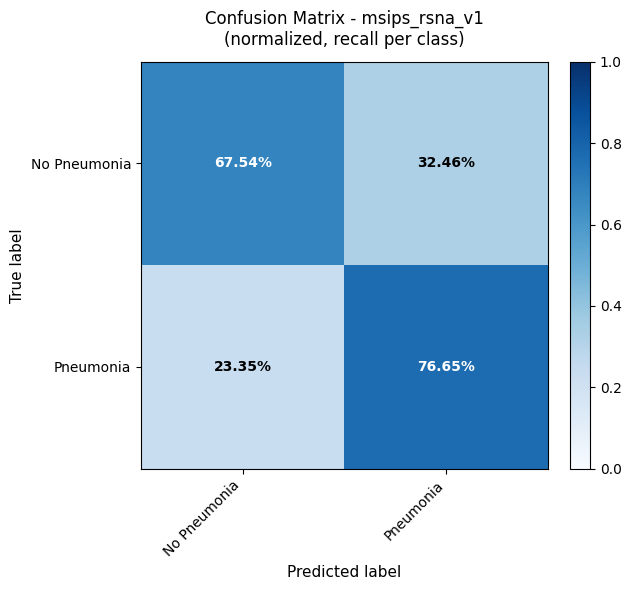


Classification Report
              precision    recall  f1-score   support

No Pneumonia       0.91      0.68      0.77      5176
   Pneumonia       0.41      0.77      0.53      1503

    accuracy                           0.70      6679
   macro avg       0.66      0.72      0.65      6679
weighted avg       0.80      0.70      0.72      6679

Probs        : {'pneumonia': array([0.5399956 , 0.46000445], dtype=float32)}
Label prédit : {'pneumonia': 0} | Label réel   : 1
Grossiers sélectionnés : 2/10
Fins sélectionnés      : 8/10


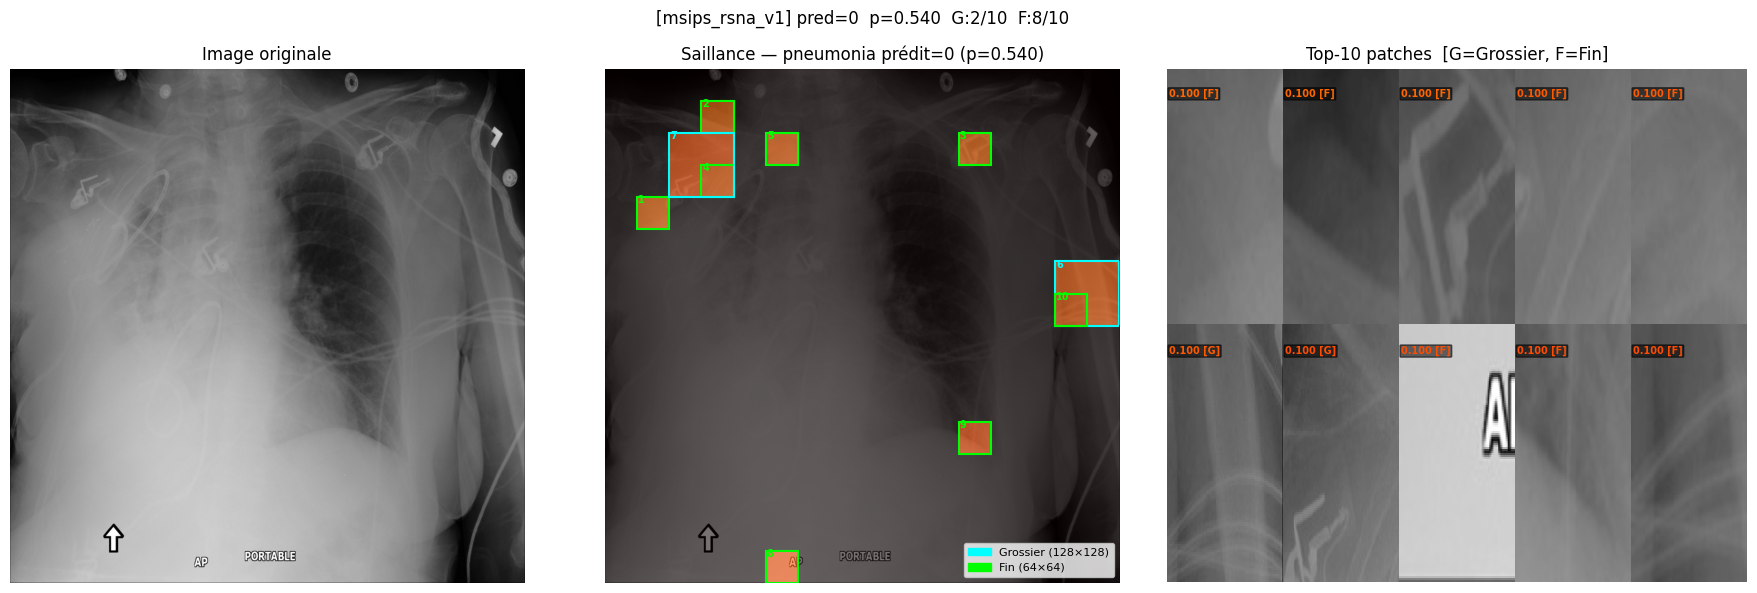

  Sauvegardé : /kaggle/working/ms-ips/rsna/saliency_rsna/msips_rsna_v1_saliency_00_img5238.png
  Patches    : /kaggle/working/ms-ips/rsna/saliency_rsna/msips_rsna_v1_patches_00_img5238.npy
  Sauvegardé : /kaggle/working/ms-ips/rsna/saliency_rsna/msips_rsna_v1_saliency_01_img912.png
  Patches    : /kaggle/working/ms-ips/rsna/saliency_rsna/msips_rsna_v1_patches_01_img912.npy
  Sauvegardé : /kaggle/working/ms-ips/rsna/saliency_rsna/msips_rsna_v1_saliency_02_img204.png
  Patches    : /kaggle/working/ms-ips/rsna/saliency_rsna/msips_rsna_v1_patches_02_img204.npy
  Sauvegardé : /kaggle/working/ms-ips/rsna/saliency_rsna/msips_rsna_v1_saliency_03_img6074.png
  Patches    : /kaggle/working/ms-ips/rsna/saliency_rsna/msips_rsna_v1_patches_03_img6074.npy
  Sauvegardé : /kaggle/working/ms-ips/rsna/saliency_rsna/msips_rsna_v1_saliency_04_img2253.png
  Patches    : /kaggle/working/ms-ips/rsna/saliency_rsna/msips_rsna_v1_patches_04_img2253.npy
CSV : /kaggle/working/ms-ips/rsna/saliency_rsna/msips_rsna_

In [52]:
# ============================================================
# STEP 3 — Runner MS-IPS (RSNA)
# ============================================================
import os
import numpy as np
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler

torch.manual_seed(msips_rsna_conf.seed)
np.random.seed(msips_rsna_conf.seed)

# ── Chemin de sauvegarde ─────────────────────────────────────
SAVE_PATH = "/kaggle/working/ms-ips/rsna"
os.makedirs(SAVE_PATH, exist_ok=True)

RUN_NAME = "msips_rsna_v1"

# ── Enregistrement DataFactory ───────────────────────────────
DataFactory._registry["msips_rsna"] = RSNADatasetMSIPS
factory = DataFactory(msips_rsna_conf, dataset="msips_rsna")

# ── WeightedRandomSampler (déséquilibre pneumonia) ───────────
labels_train = np.array([
    factory.train_data[i]['pneumonia']
    for i in range(len(factory.train_data))
])

n_pos   = labels_train.sum()
n_neg   = len(labels_train) - n_pos
w_pos   = 1.0 / n_pos
w_neg   = 1.0 / n_neg
weights = np.where(labels_train == 1, w_pos, w_neg)

sampler = WeightedRandomSampler(
    weights     = torch.from_numpy(weights).float(),
    num_samples = len(weights),
    replacement = True
)

print(f"WeightedSampler — n_pos={n_pos}, n_neg={n_neg}, "
      f"ratio={n_neg/n_pos:.2f}:1")

# ── DataLoaders ──────────────────────────────────────────────
train_loader = DataLoader(
    factory.train_data,
    batch_size         = msips_rsna_conf.B_seq,
    sampler            = sampler,
    num_workers        = msips_rsna_conf.n_worker,
    pin_memory         = msips_rsna_conf.pin_memory,
    persistent_workers = True
)

val_loader = DataLoader(
    factory.test_data,
    batch_size         = msips_rsna_conf.B_seq,
    shuffle            = False,
    num_workers        = msips_rsna_conf.n_worker,
    pin_memory         = msips_rsna_conf.pin_memory,
    persistent_workers = True
)

print(f"train batches : {len(train_loader)}")
print(f"val   batches : {len(val_loader)}")

# ── Modèle + Engine ──────────────────────────────────────────
net    = MSIPSNet(DEVICE, msips_rsna_conf)
engine = UniversalEngineMSIPS(
    net, msips_rsna_conf, DEVICE,
    run_name=RUN_NAME)
engine.summary()

# ── Entraînement (avec tracking CO₂) ────────────────────────
history = engine.fit(train_loader, val_loader)
engine.summary()

# ── Sauvegardes ──────────────────────────────────────────────
engine.save(f"{SAVE_PATH}/{RUN_NAME}.pt")
engine.save_weights(f"{SAVE_PATH}/{RUN_NAME}_weights.pt")
engine.save_history(f"{SAVE_PATH}/{RUN_NAME}_history.json")
engine.log_experiment(SAVE_PATH)

# ── Matrice de confusion ──────────────────────────────────────
cm = engine.plot_confusion_matrix(
    val_loader,
    class_names=['No Pneumonia', 'Pneumonia'],
    normalize=True,
    save_path=f"{SAVE_PATH}/{RUN_NAME}_confusion_matrix.png"
)

# ── Inférence + saillance sur un exemple ─────────────────────
sample    = factory.test_data[0]
img_check = sample['input']

result = engine.predict(img_check, return_patches=True)
print(f"Probs        : {result['probs']}")
print(f"Label prédit : {result['label']} | "
      f"Label réel   : {sample['pneumonia']}")
print(f"Grossiers sélectionnés : {(result['scales']==0).sum()}"
      f"/{msips_rsna_conf.M}")
print(f"Fins sélectionnés      : {(result['scales']==1).sum()}"
      f"/{msips_rsna_conf.M}")
engine.show_saliency(img_check, result)

save_dir, csv_path = engine.save_saliency(
    dataset  = factory.test_data,
    save_dir = f"{SAVE_PATH}/saliency_rsna",
    n_images = 5,
    seed     = 42
)

# ── CO₂ ──────────────────────────────────────────────────────
emissions = [e for e in engine.history.get("emissions", []) if e is not None]
if emissions:
    print(f"\nCO₂ total      : {sum(emissions):.6f} kg")
    print(f"CO₂ par époque : {sum(emissions)/len(emissions):.6f} kg")
else:
    print("\nCO₂ : non mesuré (codecarbon indisponible)")